<a href="https://colab.research.google.com/github/juhungaro/Pipoca/blob/main/Entrega2_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Etapa 1 – Pré-processamento dos Dados

*   Organizar os datasets de imagens e dados temporais coletados na Sprint 1.
*   Realizar tratamento dos dados, garantindo que estejam estruturados e prontos para serem usados no modelo.
*   Identificar padrões e sazonalidades na série temporal NDVI, explorando diferentes abordagens estatísticas para entender variações de produtividade.

In [2]:
# Importar as bibliotecas
import os
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf


# Verificar Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("Executando no Google Colab")
except:
    IN_COLAB = False
    print("Executando localmente")

# Configurações gerais
plt.style.use('seaborn-v0_8')
sns.set(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

# Criar diretórios para salvar resultados
def criar_diretorios():
    """
    Cria os diretórios necessários para armazenar os dados processados e resultados.
    """
    diretorios = [
        'dados_originais',
        'dados_processados',
        'resultados',
    ]

    for diretorio in diretorios:
        os.makedirs(diretorio, exist_ok=True)
        print(f"Diretório '{diretorio}' criado ou já existente.")

# Chamar a função para criar diretórios
criar_diretorios()

Executando no Google Colab
Diretório 'dados_originais' criado ou já existente.
Diretório 'dados_processados' criado ou já existente.
Diretório 'resultados' criado ou já existente.


# Dados SatVeg

Dados obtidos do sensor SatVeg para a Fazenda São José, Sorriso-MT
Coordenadas: -55.95520,-12.88229 | -55.95729,-12.88229

In [3]:
# Bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

In [4]:
# Upload do arquivo
print("1. Carregamento dos dados do SatVeg")
from google.colab import files
uploaded = files.upload()

# Carregar o arquivo CSV
filename = list(uploaded.keys())[0]
df_satveg = pd.read_csv(filename, encoding='latin1', sep=';')

# Salvar os dados originais no diretório apropriado
original_path = os.path.join('dados_originais', 'satveg_original.csv')
df_satveg.to_csv(original_path, index=False)
print(f"Dados originais salvos em: {original_path}")

# Informações básicas
print(f"Arquivo carregado: {filename}")
print(f"Dimensões: {df_satveg.shape[0]} linhas x {df_satveg.shape[1]} colunas")


1. Carregamento dos dados do SatVeg


Saving dados_satveg.csv to dados_satveg.csv
Dados originais salvos em: dados_originais/satveg_original.csv
Arquivo carregado: dados_satveg.csv
Dimensões: 576 linhas x 4 colunas


In [5]:
# Pré-processamento
print("\n Pré-processamento dos dados")

# Converter colunas data
if 'Data' in df_satveg.columns:
    df_satveg['Data'] = pd.to_datetime(df_satveg['Data'], format='%d/%m/%Y', errors='coerce')
    print("- Coluna 'Data' convertida para datetime")

# Criando colunas auxiliares
df_satveg['mes'] = df_satveg['Data'].dt.month
df_satveg['ano'] = df_satveg['Data'].dt.year

# Converter colunas numéricas
colunas_numericas = ["NDVI", "PreFiltro", "FlatBottom"]
print("- Convertendo colunas numéricas:")

for coluna in colunas_numericas:
    if coluna in df_satveg.columns:
        # Guardar tipo original para mostrar a mudança
        tipo_original = df_satveg[coluna].dtype

        # Converter de string com vírgula para float
        if df_satveg[coluna].dtype == 'object':
            df_satveg[coluna] = df_satveg[coluna].str.replace(',', '.').astype(float)
            print(f"  Coluna '{coluna}' convertida: {tipo_original} → {df_satveg[coluna].dtype}")
        else:
            print(f"  Coluna '{coluna}' já é do tipo numérico: {df_satveg[coluna].dtype}")
    else:
        print(f"  Atenção: Coluna '{coluna}' não encontrada no DataFrame")

# Verificar valores nulos
nulos = df_satveg.isnull().sum()
print("- Valores nulos por coluna:")
print(nulos[nulos > 0] if any(nulos > 0) else "  Não há valores nulos")


 Pré-processamento dos dados
- Coluna 'Data' convertida para datetime
- Convertendo colunas numéricas:
  Coluna 'NDVI' convertida: object → float64
  Coluna 'PreFiltro' convertida: object → float64
  Coluna 'FlatBottom' convertida: object → float64
- Valores nulos por coluna:
  Não há valores nulos


In [6]:
df_satveg.head()

,Data,NDVI,PreFiltro,FlatBottom,mes,ano
0,2000-02-18,0.6119,0.6542,0.6542,2,2000
1,2000-03-05,0.6542,0.6542,0.6542,3,2000
2,2000-03-21,0.5751,0.5751,0.6542,3,2000
3,2000-04-06,0.6839,0.6839,0.6839,4,2000
4,2000-04-22,0.4797,0.4797,0.4808,4,2000


In [7]:
# Garante que 'Data' está como datetime
df_satveg['Data'] = pd.to_datetime(df_satveg['Data'], errors='coerce')

# Cria a coluna 'AnoMes' no formato 'YYYY-MM'
df_satveg['AnoMes'] = df_satveg['Data'].dt.to_period('M').astype(str)

if 'NDVI' in df_satveg.columns and 'AnoMes' in df_satveg.columns:
    # Para cada mês, calcula a média e atribui a todas as linhas daquele mês
    df_satveg['NDVI_media_mensal'] = df_satveg.groupby('AnoMes')['NDVI'].transform('mean')
    print("\nColuna 'NDVI_media_mensal' adicionada ao DataFrame!")
    print(df_satveg[['Data', 'NDVI', 'AnoMes', 'NDVI_media_mensal']].head())
else:
    print("\nNão foi possível criar a média mensal do NDVI: Colunas necessárias não encontradas.")





Coluna 'NDVI_media_mensal' adicionada ao DataFrame!
        Data    NDVI   AnoMes  NDVI_media_mensal
0 2000-02-18  0.6119  2000-02            0.61190
1 2000-03-05  0.6542  2000-03            0.61465
2 2000-03-21  0.5751  2000-03            0.61465
3 2000-04-06  0.6839  2000-04            0.58180
4 2000-04-22  0.4797  2000-04            0.58180


In [8]:
# Análise Exploratória Básica
print("\n Análise Exploratória Básica")
print("- Primeiras linhas dos dados:")
display(df_satveg.head())

print("\n- Resumo estatístico das colunas numéricas:")
display(df_satveg[colunas_numericas].describe())


 Análise Exploratória Básica
- Primeiras linhas dos dados:


,Data,NDVI,PreFiltro,FlatBottom,mes,ano,AnoMes,NDVI_media_mensal
0,2000-02-18,0.6119,0.6542,0.6542,2,2000,2000-02,0.61190
1,2000-03-05,0.6542,0.6542,0.6542,3,2000,2000-03,0.61465
2,2000-03-21,0.5751,0.5751,0.6542,3,2000,2000-03,0.61465
3,2000-04-06,0.6839,0.6839,0.6839,4,2000,2000-04,0.58180
4,2000-04-22,0.4797,0.4797,0.4808,4,2000,2000-04,0.58180



- Resumo estatístico das colunas numéricas:


,NDVI,PreFiltro,FlatBottom
count,576.000000,576.000000,576.000000
mean,0.438249,0.470147,0.478435
std,0.185401,0.178731,0.176696
min,-0.300000,0.158200,0.187300
25%,0.291450,0.307225,0.310100
50%,0.391100,0.447650,0.468250
75%,0.590000,0.624850,0.629725
max,0.871500,0.871500,0.871500



 Visualização de Dados
 Histograma - Distribuição das variáveis:


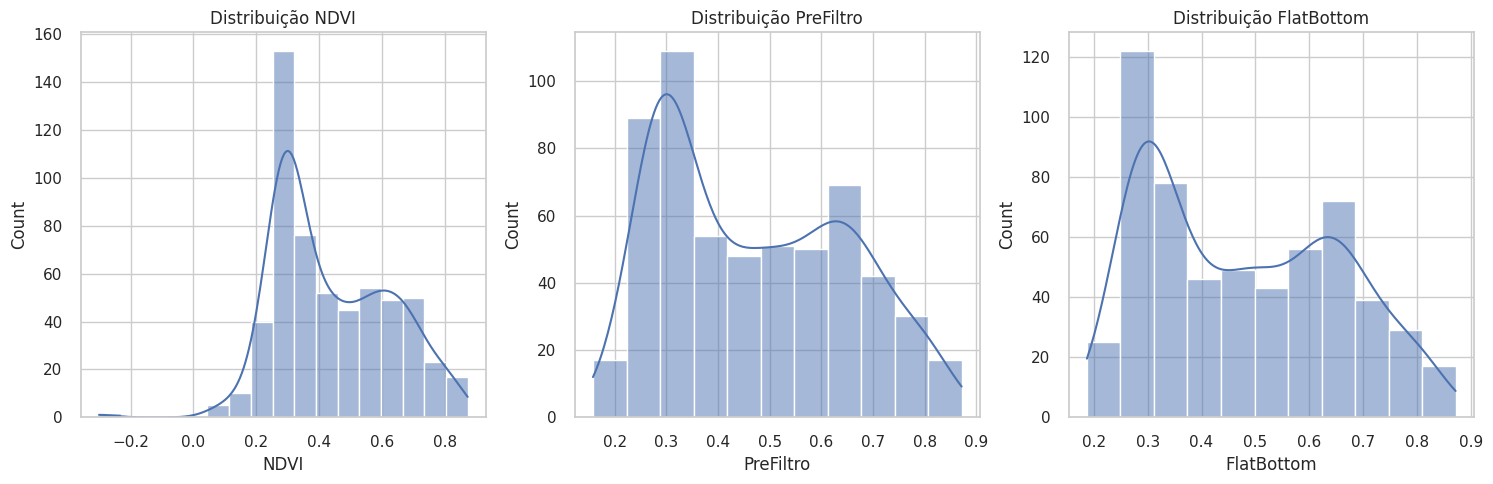

In [9]:
# Visualização de Dados
print("\n Visualização de Dados")

# 4.1 Distribuições (histogramas)
print(" Histograma - Distribuição das variáveis:")
plt.figure(figsize=(15, 5))

for i, coluna in enumerate(colunas_numericas):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_satveg[coluna], kde=True)
    plt.title(f'Distribuição {coluna}')

plt.tight_layout()
plt.show()

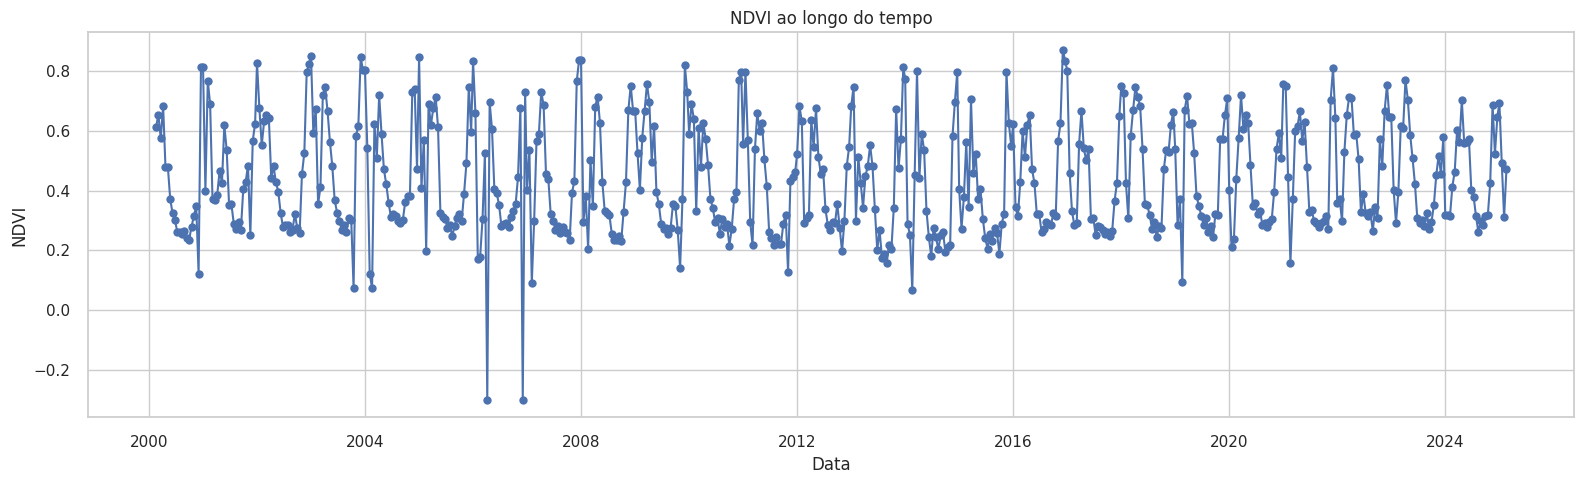

In [10]:
# Serie temporal completa
plt.figure(figsize=(16,5))
plt.plot(df_satveg['Data'], df_satveg['NDVI'], marker='o', linestyle='-')
plt.title('NDVI ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('NDVI')
plt.grid(True)
plt.tight_layout()
plt.show()


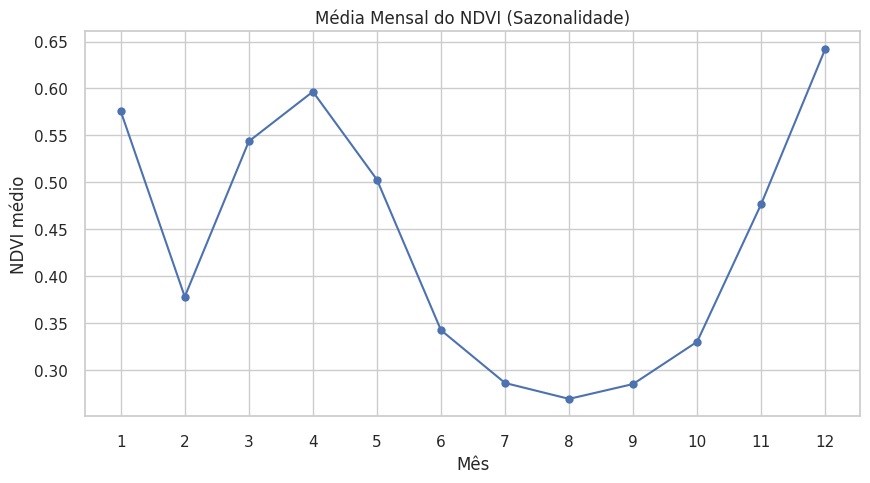

In [11]:
# Gráfico da média mensal (sazonalidade típica)
ndvi_media_mensal = df_satveg.groupby('mes')['NDVI'].mean()

plt.figure(figsize=(10,5))
plt.plot(ndvi_media_mensal.index, ndvi_media_mensal.values, marker='o')
plt.title('Média Mensal do NDVI (Sazonalidade)')
plt.xlabel('Mês')
plt.ylabel('NDVI médio')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


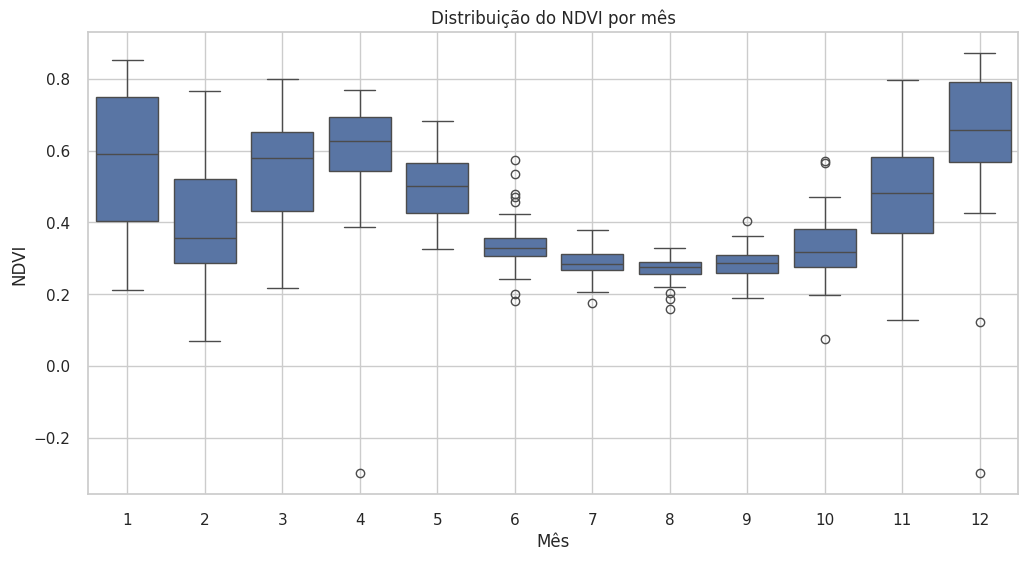

In [12]:
# Boxplot do NDVI por mês
plt.figure(figsize=(12,6))
sns.boxplot(x='mes', y='NDVI', data=df_satveg)
plt.title('Distribuição do NDVI por mês')
plt.xlabel('Mês')
plt.ylabel('NDVI')
plt.grid(True)
plt.show()


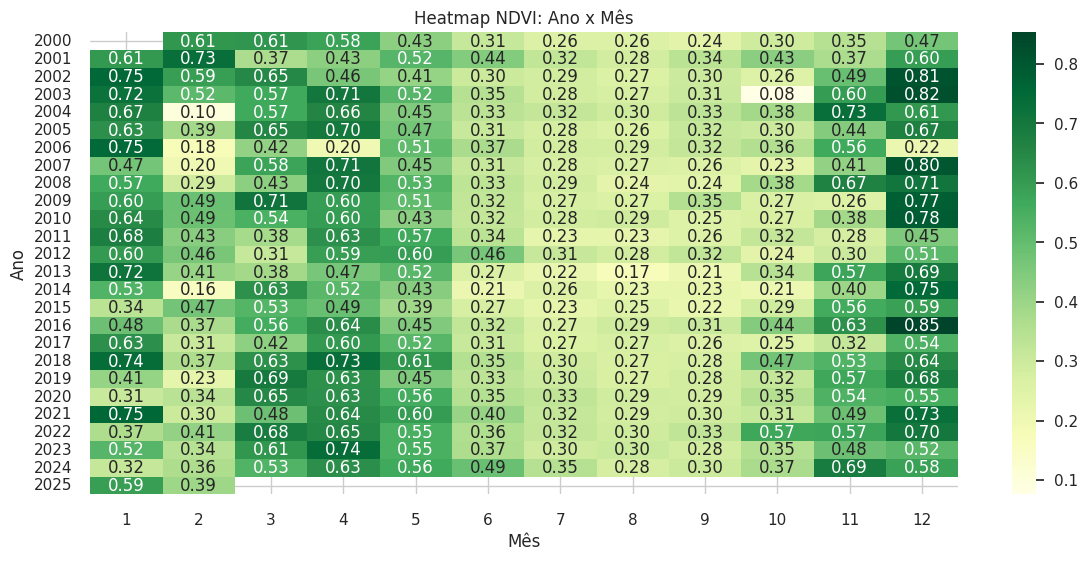

In [13]:
# Heatmap Ano vs Mês do NDVI
pivot = df_satveg.pivot_table(
    index='ano', columns='mes', values='NDVI', aggfunc='mean'
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='YlGn', annot=True, fmt=".2f")
plt.title('Heatmap NDVI: Ano x Mês')
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.show()


<ipython-input-14-cfe60985c238>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ndvi_monthly = df_satveg.set_index('Data')['NDVI'].resample('M').mean().interpolate()


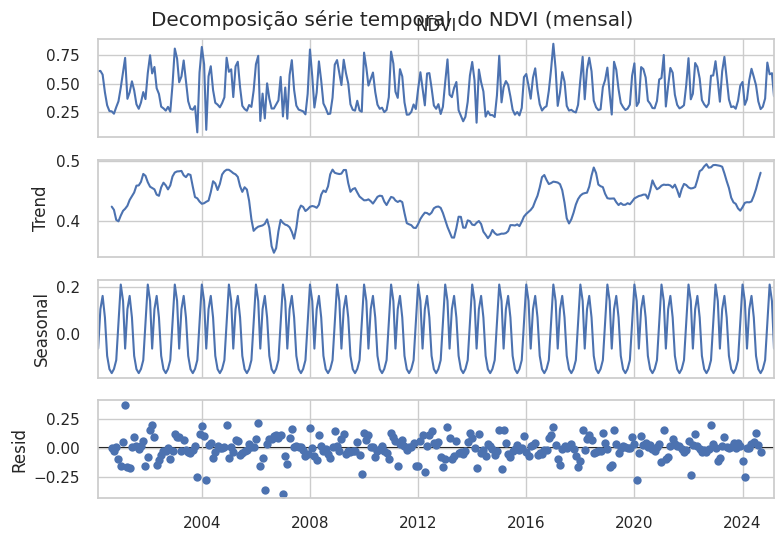

In [14]:
# Decomposição da série temporal (tendência + sazonalidade)
import statsmodels.api as sm

# Dados reagrupados mensalmente
ndvi_monthly = df_satveg.set_index('Data')['NDVI'].resample('M').mean().interpolate()

# Use the seasonal_decompose function from statsmodels.tsa.seasonal
decomp = sm.tsa.seasonal_decompose(ndvi_monthly, model='additive', period=12)
decomp.plot()
plt.suptitle('Decomposição série temporal do NDVI (mensal)')
plt.show()



 Dispersão - Relações entre variáveis:


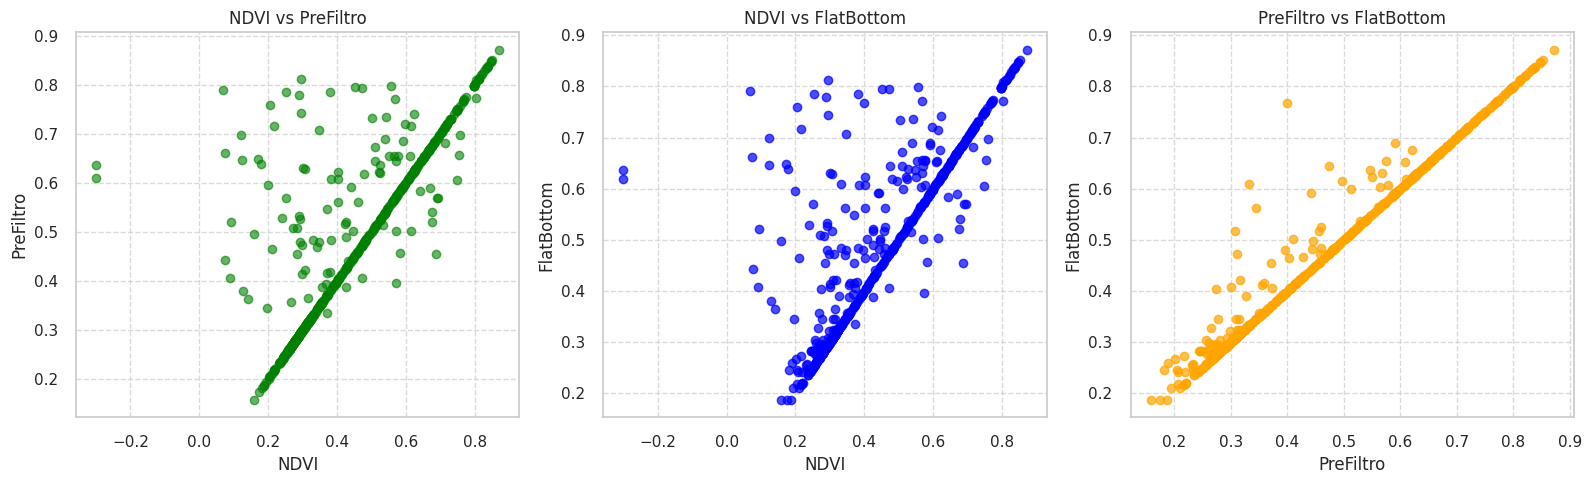

In [15]:
# Relações entre variáveis (dispersão)
print("\n Dispersão - Relações entre variáveis:")
plt.figure(figsize=(16, 5))

# Gráfico 1: NDVI vs PreFiltro
plt.subplot(1, 3, 1)
plt.scatter(df_satveg['NDVI'], df_satveg['PreFiltro'], alpha=0.6, color='green' )
plt.title('NDVI vs PreFiltro')
plt.xlabel('NDVI')
plt.ylabel('PreFiltro')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: NDVI vs FlatBottom
plt.subplot(1, 3, 2)
plt.scatter(df_satveg['NDVI'], df_satveg['FlatBottom'], alpha=0.7, color='blue')
plt.title('NDVI vs FlatBottom')
plt.xlabel('NDVI')
plt.ylabel('FlatBottom')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 3: PreFiltro vs FlatBottom
plt.subplot(1, 3, 3)
plt.scatter(df_satveg['PreFiltro'], df_satveg['FlatBottom'], alpha=0.7, color='orange')
plt.title('PreFiltro vs FlatBottom')
plt.xlabel('PreFiltro')
plt.ylabel('FlatBottom')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


 Boxplots - Comparação de distribuição entre variáveis:


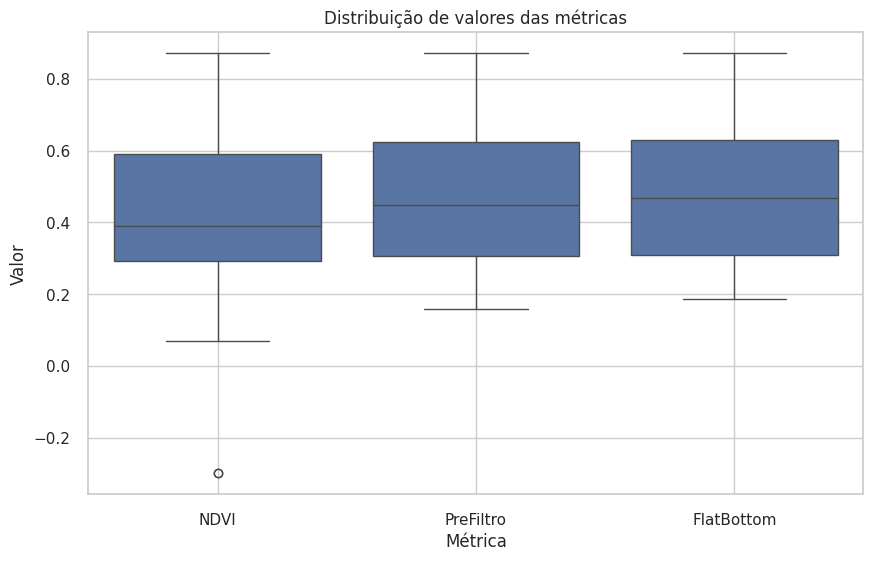

In [16]:
# Comparação de variáveis (boxplots)
print("\n Boxplots - Comparação de distribuição entre variáveis:")
plt.figure(figsize=(10, 6))
df_melt = df_satveg.melt(id_vars='Data', value_vars=colunas_numericas,
                  var_name='Métrica', value_name='Valor')
sns.boxplot(x='Métrica', y='Valor', data=df_melt)
plt.title('Distribuição de valores das métricas')
plt.grid(True)
plt.show()

In [17]:
# Salvar os dados processados no diretório do Colab
processed_path = os.path.join('dados_processados', 'satveg_processado.csv')
df_satveg.to_csv(processed_path, index=False)
print(f"- Dados processados salvos em: {processed_path}")

# Opção de download
try:
    files.download(processed_path)
    print("- Arquivo 'satveg_processado.csv' disponibilizado para download.")
except Exception as e:
    print(f"- Erro ao disponibilizar arquivo para download: {e}")

- Dados processados salvos em: dados_processados/satveg_processado.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

- Arquivo 'satveg_processado.csv' disponibilizado para download.


# Dados metereológicos INMET
Optamos por fazer download dos arquivos, pois via API ia ficar muito lento

Fonte de dados https://portal.inmet.gov.br/dadoshistoricos

In [38]:
# Bibliotecas necessárias
import glob
import pandas as pd
import numpy as np

In [18]:


# Carregamento e Consolidação dos Dados

# Upload dos arquivos
uploaded = files.upload()

# Padrão dos arquivos
arquivos = sorted(glob.glob('Clima_Sorriso_*.csv'))

print("Arquivos encontrados:", arquivos)

# Ler e concatenar os arquivos
dfs = []
for arq in arquivos:
    print("Lendo:", arq)
    df_temp = pd.read_csv(arq, sep=";", encoding='latin1')
    dfs.append(df_temp)

df_climatotal = pd.concat(dfs, ignore_index=True)

# Converter 'DATA' para datetime
df_climatotal['DATA'] = pd.to_datetime(df_climatotal['DATA'], errors='coerce')

# Visualização inicial
print("\nBase consolidada, preview:")
print(df_climatotal.head())
print(f"\nTotal de linhas lidas: {df_climatotal.shape[0]}")

Saving Clima_Sorriso_2015.csv to Clima_Sorriso_2015.csv
Saving Clima_Sorriso_2016.csv to Clima_Sorriso_2016.csv
Saving Clima_Sorriso_2017.csv to Clima_Sorriso_2017.csv
Saving Clima_Sorriso_2018.csv to Clima_Sorriso_2018.csv
Saving Clima_Sorriso_2019.csv to Clima_Sorriso_2019.csv
Saving Clima_Sorriso_2020.csv to Clima_Sorriso_2020.csv
Saving Clima_Sorriso_2023.csv to Clima_Sorriso_2023.csv
Saving Clima_Sorriso_2024.csv to Clima_Sorriso_2024.csv
Saving Clima_Sorriso_2025.csv to Clima_Sorriso_2025.csv
Arquivos encontrados: ['Clima_Sorriso_2015.csv', 'Clima_Sorriso_2016.csv', 'Clima_Sorriso_2017.csv', 'Clima_Sorriso_2018.csv', 'Clima_Sorriso_2019.csv', 'Clima_Sorriso_2020.csv', 'Clima_Sorriso_2023.csv', 'Clima_Sorriso_2024.csv', 'Clima_Sorriso_2025.csv']
Lendo: Clima_Sorriso_2015.csv
Lendo: Clima_Sorriso_2016.csv
Lendo: Clima_Sorriso_2017.csv
Lendo: Clima_Sorriso_2018.csv
Lendo: Clima_Sorriso_2019.csv
Lendo: Clima_Sorriso_2020.csv
Lendo: Clima_Sorriso_2023.csv
Lendo: Clima_Sorriso_2024.csv

In [19]:
# Salvar Dados Originais

# Criar diretório se não existir
os.makedirs('dados_originais', exist_ok=True)

# Salvar arquivos originais e criar lista para compactar
arquivos_originais_salvos = []
for arq in arquivos:
    original_data = pd.read_csv(arq, sep=";", encoding='latin1')
    original_path = os.path.join('dados_originais', arq)
    original_data.to_csv(original_path, sep=';', index=False, encoding='latin1')
    arquivos_originais_salvos.append(original_path)
    print(f"Arquivo original salvo em: {original_path}")

Arquivo original salvo em: dados_originais/Clima_Sorriso_2015.csv
Arquivo original salvo em: dados_originais/Clima_Sorriso_2016.csv
Arquivo original salvo em: dados_originais/Clima_Sorriso_2017.csv
Arquivo original salvo em: dados_originais/Clima_Sorriso_2018.csv
Arquivo original salvo em: dados_originais/Clima_Sorriso_2019.csv
Arquivo original salvo em: dados_originais/Clima_Sorriso_2020.csv
Arquivo original salvo em: dados_originais/Clima_Sorriso_2023.csv
Arquivo original salvo em: dados_originais/Clima_Sorriso_2024.csv
Arquivo original salvo em: dados_originais/Clima_Sorriso_2025.csv


In [20]:
# Tratamento dos Dados
# Validar datas
df_climatotal['DATA'] = pd.to_datetime(df_climatotal['DATA'], format='%d/%m/%Y', errors='coerce')

# Encontrar menor e maior data
menor_data = df_climatotal['DATA'].min()
maior_data = df_climatotal['DATA'].max()

print("Menor data:", menor_data.strftime('%d/%m/%Y') if pd.notna(menor_data) else "Nenhuma data")
print("Maior data:", maior_data.strftime('%d/%m/%Y') if pd.notna(maior_data) else "Nenhuma data")

# Tratar valores ausentes
df_climatotal['RADIACAO'] = df_climatotal['RADIACAO'].replace(-9999, np.nan)
df_climatotal['TEMPERATURA'] = df_climatotal['TEMPERATURA'].replace(-9999, np.nan)

# Remover coluna
df_climatotal = df_climatotal.drop('RADIACA', axis=1, errors='ignore')

# Tratar valores inválidos
df_climatotal.loc[df_climatotal['RADIACAO'] < 0, 'RADIACAO'] = np.nan

# Criar colunas
df_climatotal['ANO_MES'] = df_climatotal['DATA'].dt.strftime('%Y-%m')
df_climatotal['ANO'] = df_climatotal['DATA'].dt.year.astype('Int64')
df_climatotal['MES'] = df_climatotal['DATA'].dt.month.astype('Int64')

# --- Calculate and add daily averages ---
# Define column names for radiation and temperature here:
clima_rad_col = 'RADIACAO'  # Assuming 'RADIACAO' is your radiation column
clima_temp_col = 'TEMPERATURA'  # Assuming 'TEMPERATURA' is your temperature column

# 1. Create a 'date_only' column for grouping
df_climatotal['date_only'] = df_climatotal['DATA'].dt.date

# 2. Group by 'date_only' and calculate daily averages
daily_averages = df_climatotal.groupby('date_only')[[clima_rad_col, clima_temp_col]].mean()
# 3. Rename the average columns
daily_averages = daily_averages.rename(columns={
    clima_rad_col: 'RADIACAO_media_diaria',
    clima_temp_col: 'TEMPERATURA_media_diaria'
})

# 4. Merge the daily averages back into the original DataFrame
# Reseting index before merge to avoid errors
df_climatotal = pd.merge(df_climatotal, daily_averages.reset_index(), on='date_only', how='left')

# --- (Optional) Remove the temporary 'date_only' column ---
df_climatotal = df_climatotal.drop(columns=['date_only'])

# --- Remove null values ---
# This line removes rows with any null values in the specified columns
df_climatotal.dropna(subset=['RADIACAO_media_diaria', 'TEMPERATURA_media_diaria'], inplace=True)

print(df_climatotal[['DATA', 'ANO', 'MES', 'ANO_MES', 'RADIACAO', 'TEMPERATURA', 'RADIACAO_media_diaria', 'TEMPERATURA_media_diaria']].head())


Menor data: 01/01/2015
Maior data: 03/12/2025
        DATA   ANO  MES  ANO_MES  RADIACAO  TEMPERATURA  \
0 2015-01-01  2015    1  2015-01       NaN         23.0   
1 2015-01-01  2015    1  2015-01       NaN         23.1   
2 2015-01-01  2015    1  2015-01       NaN         22.9   
3 2015-01-01  2015    1  2015-01       NaN         22.7   
4 2015-01-01  2015    1  2015-01       NaN         22.4   

   RADIACAO_media_diaria  TEMPERATURA_media_diaria  
0            1844.128571                 26.179167  
1            1844.128571                 26.179167  
2            1844.128571                 26.179167  
3            1844.128571                 26.179167  
4            1844.128571                 26.179167  


In [21]:
# Análise de nulos, duplicados e tipos

print("\nValores nulos por coluna:")
print(df_climatotal.isnull().sum())

print("\nPorcentagem de nulos:")
print(df_climatotal.isnull().mean().sort_values(ascending=False) * 100)

print("\nQtde de linhas duplicadas:", df_climatotal.duplicated().sum())

print(df_climatotal.dtypes)

print(df_climatotal.head())



Valores nulos por coluna:
DATA                            0
HORA                            0
RADIACAO                    10682
TEMPERATURA                    52
ANO_MES                         0
ANO                             0
MES                             0
RADIACAO_media_diaria           0
TEMPERATURA_media_diaria        0
dtype: int64

Porcentagem de nulos:
RADIACAO                    45.932233
TEMPERATURA                  0.223598
DATA                         0.000000
HORA                         0.000000
ANO_MES                      0.000000
ANO                          0.000000
MES                          0.000000
RADIACAO_media_diaria        0.000000
TEMPERATURA_media_diaria     0.000000
dtype: float64

Qtde de linhas duplicadas: 0
DATA                        datetime64[ns]
HORA                                object
RADIACAO                           float64
TEMPERATURA                        float64
ANO_MES                             object
ANO                          

In [22]:
# Análise Exploratória

print(df_climatotal.describe())


                                DATA      RADIACAO   TEMPERATURA         ANO  \
count                          23256  12574.000000  23204.000000     23256.0   
mean   2019-12-10 12:20:03.715170304   1343.631931     25.147057  2019.47162   
min              2015-01-01 00:00:00      0.000000      3.800000      2015.0   
25%              2016-09-03 00:00:00    347.600000     22.300000      2016.0   
50%              2019-06-03 00:00:00   1272.100000     24.300000      2019.0   
75%              2023-07-10 00:00:00   2265.025000     28.500000      2023.0   
max              2025-12-03 00:00:00   4127.700000     39.400000      2025.0   
std                              NaN   1025.743198      4.932730    3.342495   

            MES  RADIACAO_media_diaria  TEMPERATURA_media_diaria  
count   23256.0           23256.000000              23256.000000  
mean   6.477812            1349.637828                 25.148712  
min         1.0             219.100000                  9.241667  
25%        

In [23]:
# Análise de outliers (RADIACAO)
print('RADIACAO → mínimo:', df_climatotal['RADIACAO'].min(), 'máximo:', df_climatotal['RADIACAO'].max())
print('Primeiros 10 valores de RADIACAO:', df_climatotal['RADIACAO'].head(10).values)

RADIACAO → mínimo: 0.0 máximo: 4127.7
Primeiros 10 valores de RADIACAO: [nan nan nan nan nan nan nan nan nan nan]


In [24]:
# Análise de outliers (TEMPERATURA)
print('TEMPERATURA → mínimo:', df_climatotal['TEMPERATURA'].min(), 'máximo:', df_climatotal['TEMPERATURA'].max())
print('Primeiros 10 valores de TEMPERATURA:', df_climatotal['TEMPERATURA'].head(10).values)

TEMPERATURA → mínimo: 3.8 máximo: 39.4
Primeiros 10 valores de TEMPERATURA: [23.  23.1 22.9 22.7 22.4 22.4 22.1 22.  21.9 21.8]


In [25]:
# Função para remover outliers
def remover_outliers_std(df, coluna, n_std=3):
    if coluna not in df.columns:
        print(f"Coluna '{coluna}' não encontrada no DataFrame.")
        return df
    media = df[coluna].mean()
    std = df[coluna].std()
    limite_superior = media + n_std * std
    limite_inferior = media - n_std * std
    df_sem_outliers = df[(df[coluna] <= limite_superior) & (df[coluna] >= limite_inferior)].copy()
    print(f"Removendo outliers de '{coluna}' (original: {len(df)}, após: {len(df_sem_outliers)})")
    return df_sem_outliers

df_climatotal = remover_outliers_std(df_climatotal, 'RADIACAO', n_std=3)
df_climatotal = remover_outliers_std(df_climatotal, 'TEMPERATURA', n_std=3)

df_climatotal = df_climatotal.reset_index(drop=True)

print(df_climatotal.describe())


Removendo outliers de 'RADIACAO' (original: 23256, após: 12574)
Removendo outliers de 'TEMPERATURA' (original: 12574, após: 12424)
                                DATA      RADIACAO   TEMPERATURA          ANO  \
count                          12424  12424.000000  12424.000000      12424.0   
mean   2019-12-29 13:24:43.580167424   1339.268271     27.228759  2019.524227   
min              2015-01-01 00:00:00      0.000000     11.100000       2015.0   
25%              2016-09-09 00:00:00    342.875000     23.400000       2016.0   
50%              2019-06-11 12:00:00   1260.450000     27.700000       2019.0   
75%              2023-08-02 00:00:00   2255.925000     31.100000       2023.0   
max              2025-12-03 00:00:00   4127.700000     39.400000       2025.0   
std                              NaN   1026.408543      5.004896     3.344993   

            MES  RADIACAO_media_diaria  TEMPERATURA_media_diaria  
count   12424.0           12424.000000              12424.000000  
mean 


Visualização de Dados


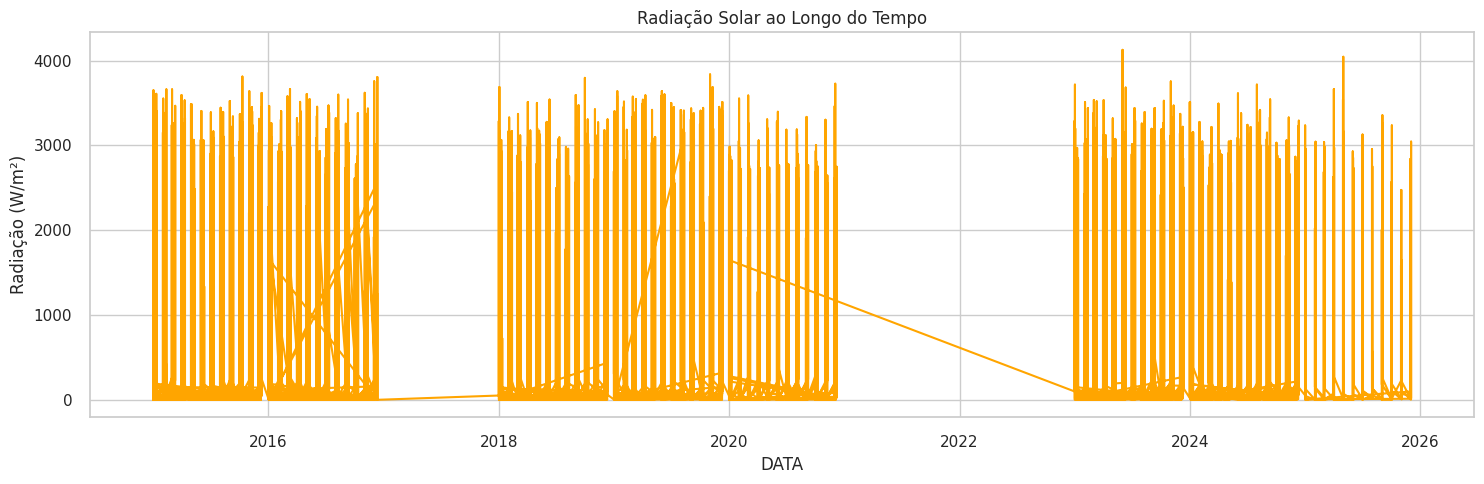

In [26]:
# Visualização
print("\nVisualização de Dados")

# Gráficos e serie temporal
plt.figure(figsize=(15, 5))
plt.plot(df_climatotal['DATA'], df_climatotal['RADIACAO'], color='orange')
plt.xlabel('DATA')
plt.ylabel('Radiação (W/m²)')
plt.title('Radiação Solar ao Longo do Tempo')
plt.grid(True)
plt.tight_layout()
plt.show()

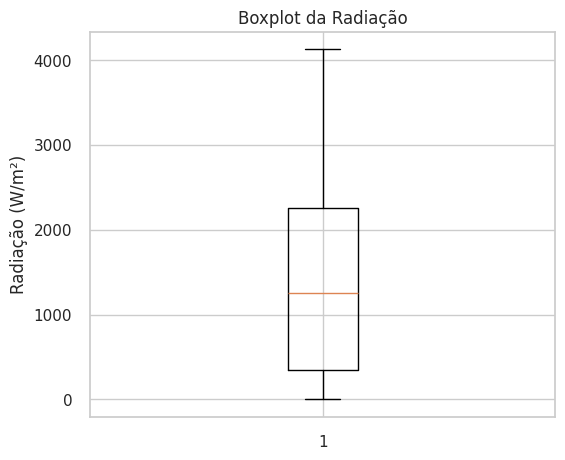

In [27]:
# Boxplot (RADIACAO total)
plt.figure(figsize=(6,5))
plt.boxplot(df_climatotal['RADIACAO'].dropna())
plt.ylabel('Radiação (W/m²)')
plt.title('Boxplot da Radiação')
plt.show()



<Figure size 1000x600 with 0 Axes>

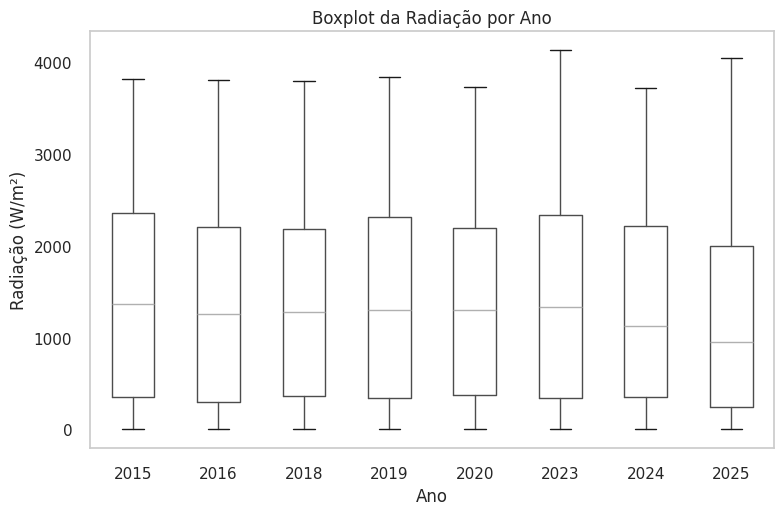

In [28]:
# Boxplot ano a ano RADIACAO
plt.figure(figsize=(10,6))
df_climatotal.boxplot(column='RADIACAO', by='ANO', grid=False)
plt.xlabel('Ano')
plt.ylabel('Radiação (W/m²)')
plt.title('Boxplot da Radiação por Ano')
plt.suptitle('')
plt.tight_layout()
plt.show()


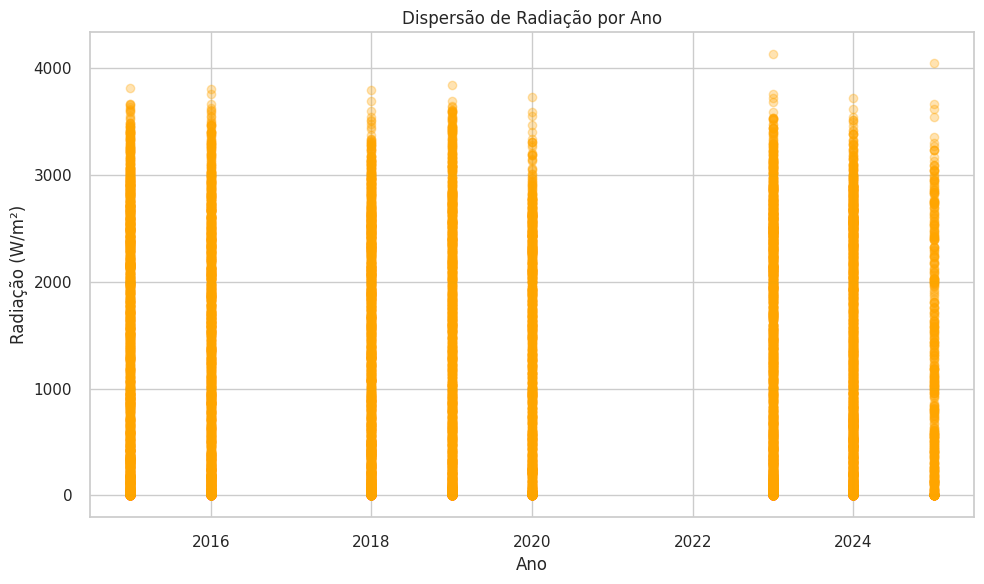

In [29]:
# Gráfico de dispersão - Radiação x Ano
plt.figure(figsize=(10,6))
plt.scatter(df_climatotal['ANO'], df_climatotal['RADIACAO'], alpha=0.3, color='orange')
plt.xlabel('Ano')
plt.ylabel('Radiação (W/m²)')
plt.title('Dispersão de Radiação por Ano')
plt.grid(True)
plt.tight_layout()
plt.show()


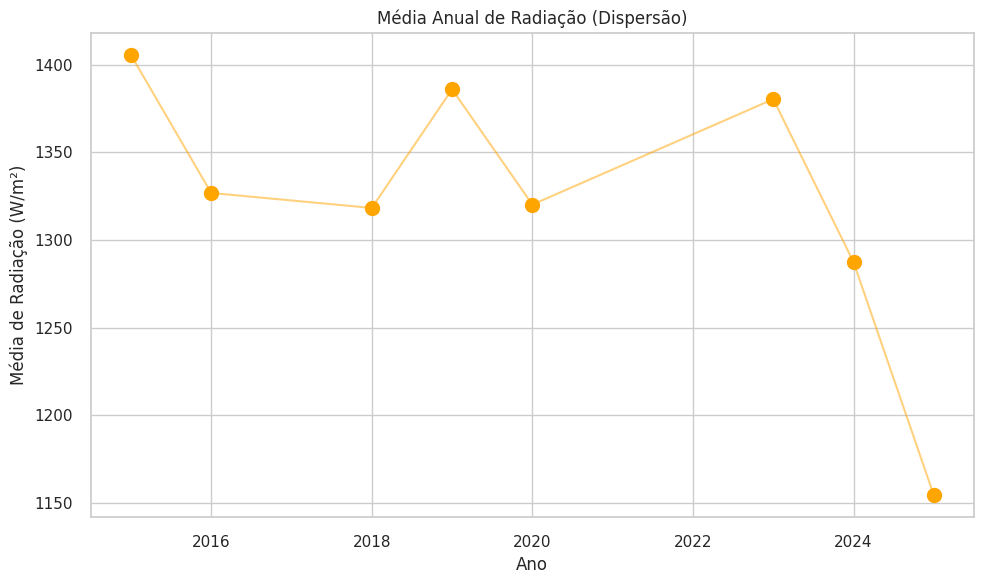

In [30]:
# Dispersão - Médias anuais RADIACAO
media_ano = df_climatotal.groupby('ANO')['RADIACAO'].mean().reset_index()

plt.figure(figsize=(10,6))
plt.scatter(media_ano['ANO'], media_ano['RADIACAO'], s=100, color='orange')
plt.plot(media_ano['ANO'], media_ano['RADIACAO'], color='orange', alpha=0.5)  # Linha para facilitar tendência
plt.xlabel('Ano')
plt.ylabel('Média de Radiação (W/m²)')
plt.title('Média Anual de Radiação (Dispersão)')
plt.grid(True)
plt.tight_layout()
plt.show()


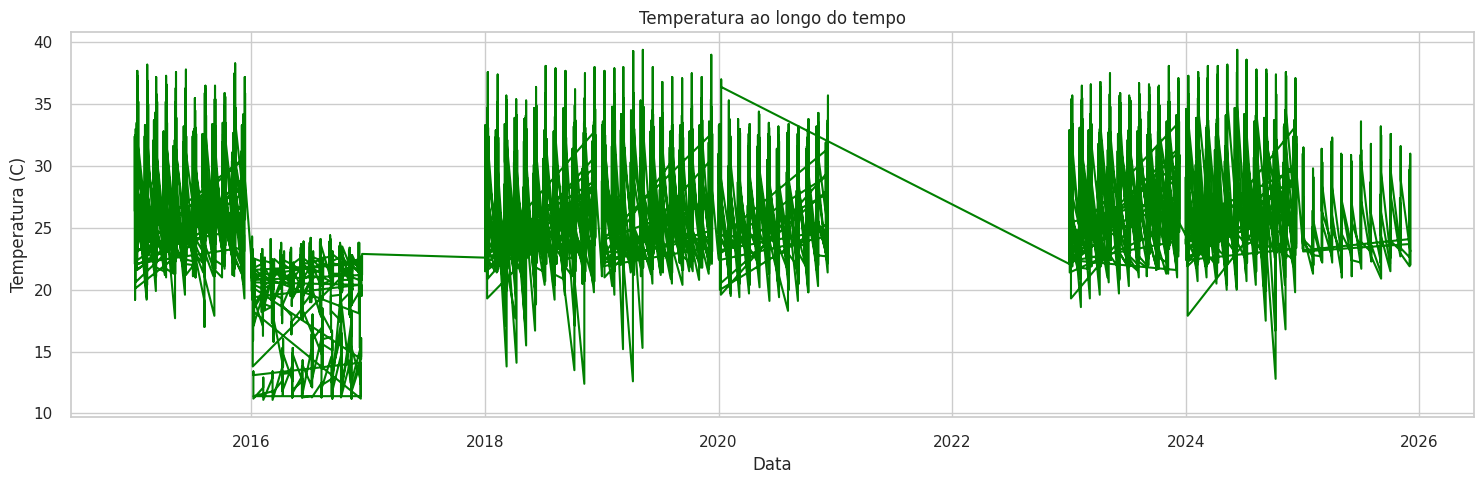

In [31]:
# Gráfico de serie temporal TEMPERATURA
plt.figure(figsize=(15,5))
plt.plot(df_climatotal['DATA'], df_climatotal['TEMPERATURA'], color='green')
plt.xlabel('Data')
plt.ylabel('Temperatura (C)')
plt.title('Temperatura ao longo do tempo')
plt.grid(True)
plt.tight_layout()
plt.show()

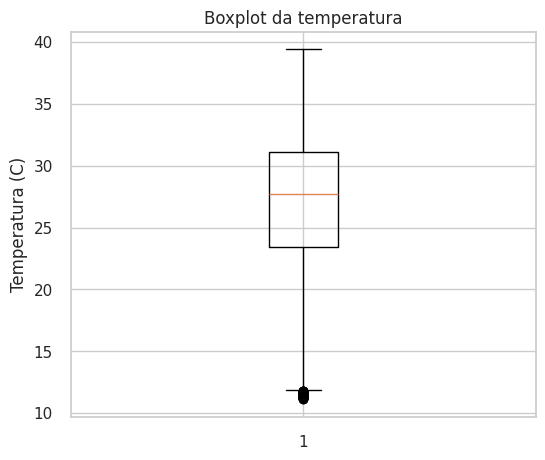

In [32]:
# Boxplot ( TEMPERATURA total)
plt.figure(figsize=(6,5))
plt.boxplot(df_climatotal['TEMPERATURA'].dropna())
plt.ylabel('Temperatura (C)')
plt.title('Boxplot da temperatura')
plt.show()


<Figure size 1000x600 with 0 Axes>

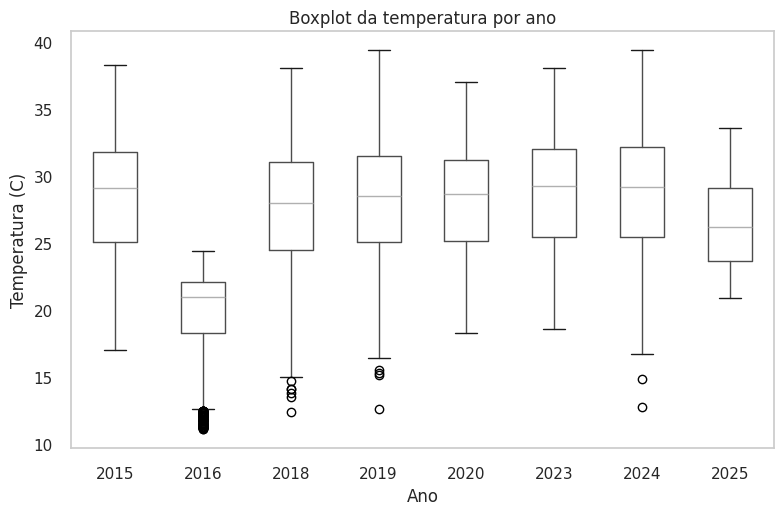

In [33]:
# Boxplot ano a ano TEMPERATURA
plt.figure(figsize=(10,6))
df_climatotal.boxplot(column='TEMPERATURA', by='ANO', grid=False)
plt.xlabel('Ano')
plt.ylabel('Temperatura (C)')
plt.title('Boxplot da temperatura por ano')
plt.suptitle('')
plt.tight_layout()
plt.show()

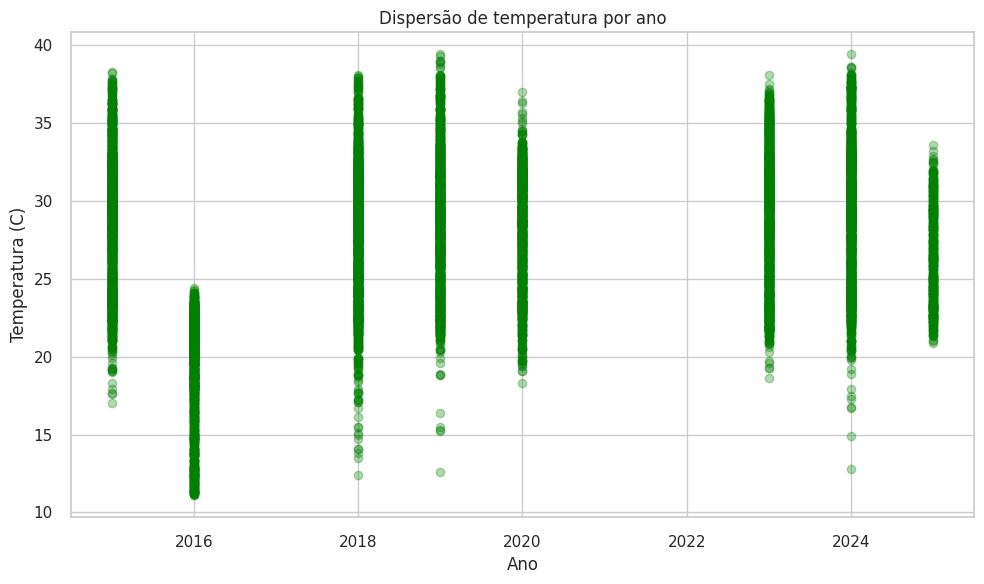

In [34]:
# Gráfico de dispersão - TEMPERATURA x Ano
plt.figure(figsize=(10,6))
plt.scatter(df_climatotal['ANO'], df_climatotal['TEMPERATURA'], alpha=0.3, color='green')
plt.xlabel('Ano')
plt.ylabel('Temperatura (C)')
plt.title('Dispersão de temperatura por ano')
plt.grid(True)
plt.tight_layout()
plt.show()

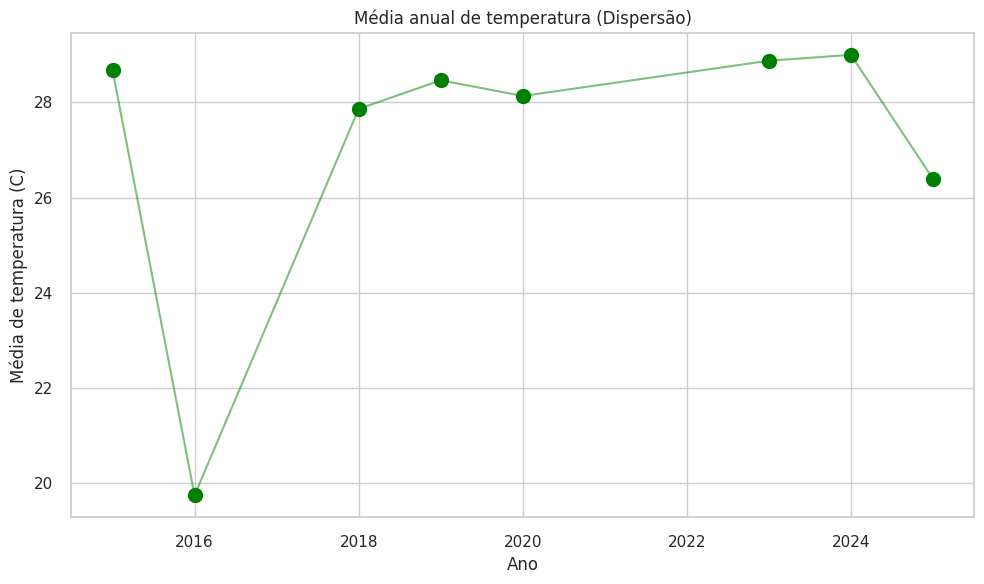

In [35]:
# Dispersão - TEMPERATURA Médias anuais
media_ano = df_climatotal.groupby('ANO')['TEMPERATURA'].mean().reset_index()

plt.figure(figsize=(10,6))
plt.scatter(media_ano['ANO'], media_ano['TEMPERATURA'], s=100, color='green')
plt.plot(media_ano['ANO'], media_ano['TEMPERATURA'], color='green', alpha=0.5)  # Linha para facilitar tendência
plt.xlabel('Ano')
plt.ylabel('Média de temperatura (C)')
plt.title('Média anual de temperatura (Dispersão)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# Salvar dados processados


processed_path = os.path.join('dados_processados', 'clima_consolidado.csv')
df_climatotal.to_csv(processed_path, index=False)
print(f"DataFrame climático consolidado salvo em: {processed_path}")



DataFrame climático consolidado salvo em: dados_processados/clima_consolidado.csv


# Produção agrícola 🌱🌽
Fonte de dados CONAB, série histórica grãos https://portaldeinformacoes.conab.gov.br/downloads/arquivos/SerieHistoricaGraos.txt



In [53]:
# Bibliotecas necessárias
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import altair as alt
import os
from google.colab import files
import zipfile

In [106]:
# Upload de arquivo

from google.colab import files
uploaded = files.upload()

# Check dos arquivos carregados
df = pd.read_csv("serie_historica_graos.csv", sep=";", encoding='latin1')
print("\nVisualização correta do arquivo:")
print(df.head())

Saving serie_historica_graos.csv to serie_historica_graos (2).csv

Visualização correta do arquivo:
           ano_agricola dsc_safra_previsao  uf  \
0  1976/77                 UNICA            AL   
1  1976/77                 UNICA            BA   
2  1976/77                 UNICA            CE   
3  1976/77                 UNICA            GO   
4  1976/77                 UNICA            MA   

                                    produto  id_produto  area_plantada_mil_ha  \
0  ALGODAO EM PLUMA                                4586                  99.3   
1  ALGODAO EM PLUMA                                4586                 123.4   
2  ALGODAO EM PLUMA                                4586                1296.0   
3  ALGODAO EM PLUMA                                4586                  73.1   
4  ALGODAO EM PLUMA                                4586                  44.4   

   producao_mil_t  produtividade_mil_ha_mil_t  
0             6.0                         0.1  
1             7.

In [107]:
# Check dos arquivos carregados
df = pd.read_csv("serie_historica_graos.csv", sep=";", encoding='latin1')
print("\nVisualização correta do arquivo:")
print(df.head())


Visualização correta do arquivo:
           ano_agricola dsc_safra_previsao  uf  \
0  1976/77                 UNICA            AL   
1  1976/77                 UNICA            BA   
2  1976/77                 UNICA            CE   
3  1976/77                 UNICA            GO   
4  1976/77                 UNICA            MA   

                                    produto  id_produto  area_plantada_mil_ha  \
0  ALGODAO EM PLUMA                                4586                  99.3   
1  ALGODAO EM PLUMA                                4586                 123.4   
2  ALGODAO EM PLUMA                                4586                1296.0   
3  ALGODAO EM PLUMA                                4586                  73.1   
4  ALGODAO EM PLUMA                                4586                  44.4   

   producao_mil_t  produtividade_mil_ha_mil_t  
0             6.0                         0.1  
1             7.0                         0.1  
2            70.0                 

In [118]:
#  Tratamento e Filtragem

# Filter for 'MT':
df_mt = df[df['uf'] == 'MT']
df = pd.read_csv("serie_historica_graos.csv", sep=";", encoding='latin1')


# Separar o ano_agricola em primeiro_ano e segundo_ano
def separa_anos(ano_agricola): # Removed 'def_mt'
    if isinstance(ano_agricola, str) and '/' in ano_agricola:
        a1, a2 = ano_agricola.split('/')
        return a1.strip(), a2.strip()
    elif isinstance(ano_agricola, str):
        return ano_agricola.strip(), None
    else:
        return None, None

anos = df['ano_agricola'].apply(separa_anos)
df['primeiro_ano'] = anos.str[0]
df['segundo_ano'] = anos.str[1]

# Renomear colunas
df = df.rename(columns={
    'dsc_safra_previsao': 'safra',
    'area_plantada_mil_ha': 'area_plantada',
    'producao_mil_t': 'producao',
    'produtividade_mil_ha_mil_t': 'produtividade'
})

# Corrigir caracteres na coluna safra
def padroniza_safra(s):
    if not isinstance(s, str): return s
    s = s.upper().strip()
    s = re.sub(r'1[ÂAªAa]*\s*SAFRA', '1ª SAFRA', s) # Corrige variantes de 1ª SAFRA
    s = re.sub(r'2[ÂAªAa]*\s*SAFRA', '2ª SAFRA', s) # Corrige variantes de 2ª SAFRA
    s = re.sub(r'3[ÂAªAa]*\s*SAFRA', '3ª SAFRA', s) # Corrige variantes de 3ª SAFRA
    s = re.sub(r'UNICA', 'ÚNICA', s) # Se tiver 'UNICA' transforma em 'ÚNICA'
    return s.title()

df['safra'] = df['safra'].apply(padroniza_safra)

# Filtrar somente produto MILHO (independente de espaços maiúsculas ou acentuação)
df = df[df['produto'].str.strip().str.upper() == 'MILHO']

# Selecionar colunas finais na ordem desejada
colunas = [
    'ano_agricola', 'primeiro_ano', 'segundo_ano', 'safra',
    'uf', 'produto', 'area_plantada', 'producao', 'produtividade'
]
df_milho = df[colunas].reset_index(drop=True)

# FILTRAR PRIMEIRO_ANO >= 2015
df_milho['primeiro_ano'] = pd.to_numeric(df_milho['primeiro_ano'], errors='coerce')
df_milho = df_milho[df_milho['primeiro_ano'] >= 2015].dropna() # Filtra e dropa NaNs


# Remover valores nulos nas colunas principais
df_milho = df_milho.dropna(subset=[
    'ano_agricola', 'primeiro_ano', 'segundo_ano', 'safra',
    'area_plantada', 'producao', 'produtividade'
]).reset_index(drop=True)

# Print para conferir se sobraram nulos
print("\nValores nulos por coluna:")
print(df_milho.isnull().sum())

# Visualização final
print(f"\nBase consolidada: {df_milho.shape[0]} linhas x {df_milho.shape[1]} colunas.")
print(df_milho.head())
print(f"O DataFrame tem {df_milho.shape[0]} linhas e {df_milho.shape[1]} colunas.")

# Salvar dados processados
processed_path = os.path.join('dados_processados', 'milho.csv')
df_milho.to_csv(processed_path, index=False)
print(f"DataFrame milho salvo em: {processed_path}")


Valores nulos por coluna:
ano_agricola     0
primeiro_ano     0
segundo_ano      0
safra            0
uf               0
produto          0
area_plantada    0
producao         0
produtividade    0
dtype: int64

Base consolidada: 661 linhas x 9 colunas.
           ano_agricola  primeiro_ano segundo_ano     safra  uf  \
0  2015/16                       2015          16  1ª Safra  AC   
1  2015/16                       2015          16  2ª Safra  AL   
2  2015/16                       2015          16  1ª Safra  AM   
3  2015/16                       2015          16  1ª Safra  AP   
4  2015/16                       2015          16  1ª Safra  BA   

                                    produto  area_plantada  producao  \
0  MILHO                                              40.0      97.0   
1  MILHO                                              30.0      28.0   
2  MILHO                                               5.0      14.0   
3  MILHO                                               

In [109]:
# Análise Exploratória
print(df_milho.describe())

       primeiro_ano  area_plantada      producao  produtividade
count    661.000000     661.000000    661.000000     661.000000
mean    2020.210287     290.347352   1545.430408       2.825567
std        2.667927     809.127938   4963.922970       2.917725
min     2015.000000       0.000000      0.000000       0.000000
25%     2018.000000       0.000000      0.000000       0.000000
50%     2020.000000      29.000000     71.100000       2.600000
75%     2022.000000     264.300000   1051.000000       5.000000
max     2024.000000    7367.300000  50731.200000      11.600000



Histograma - Distribuição das variáveis:


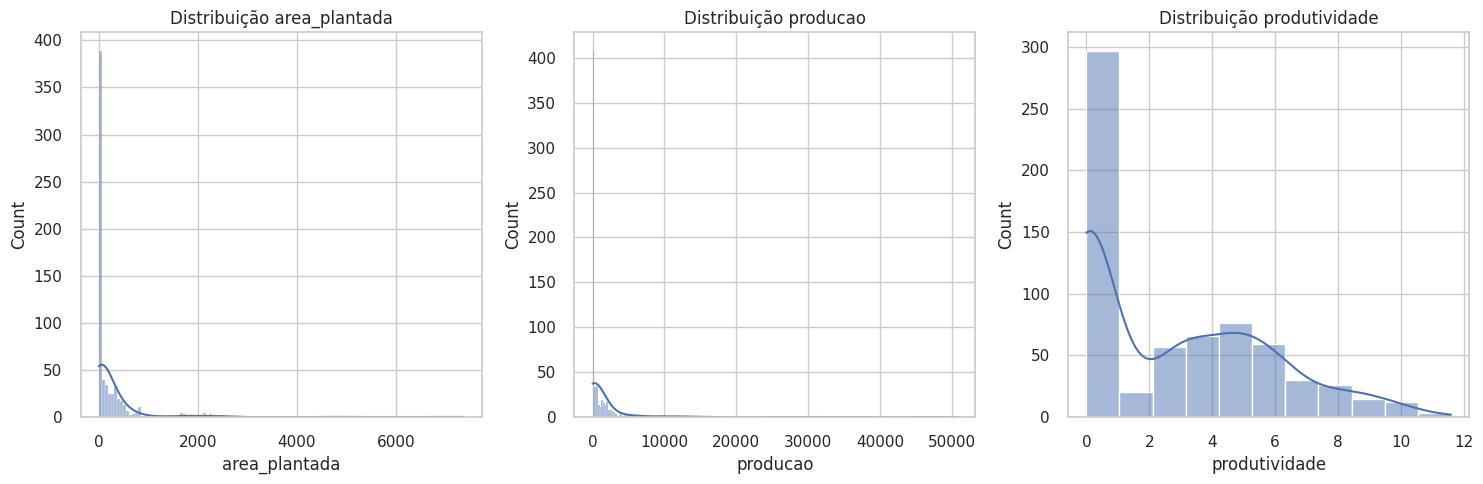

In [110]:
# Visualização de dados

# Distribuições (histogramas)
print("\nHistograma - Distribuição das variáveis:")
plt.figure(figsize=(15, 5))

colunas_numericas = ['area_plantada', 'producao', 'produtividade']

for i, coluna in enumerate(colunas_numericas):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_milho[coluna], kde=True)
    plt.title(f'Distribuição {coluna}')

plt.tight_layout()
plt.show()


Evolução temporal das métricas:


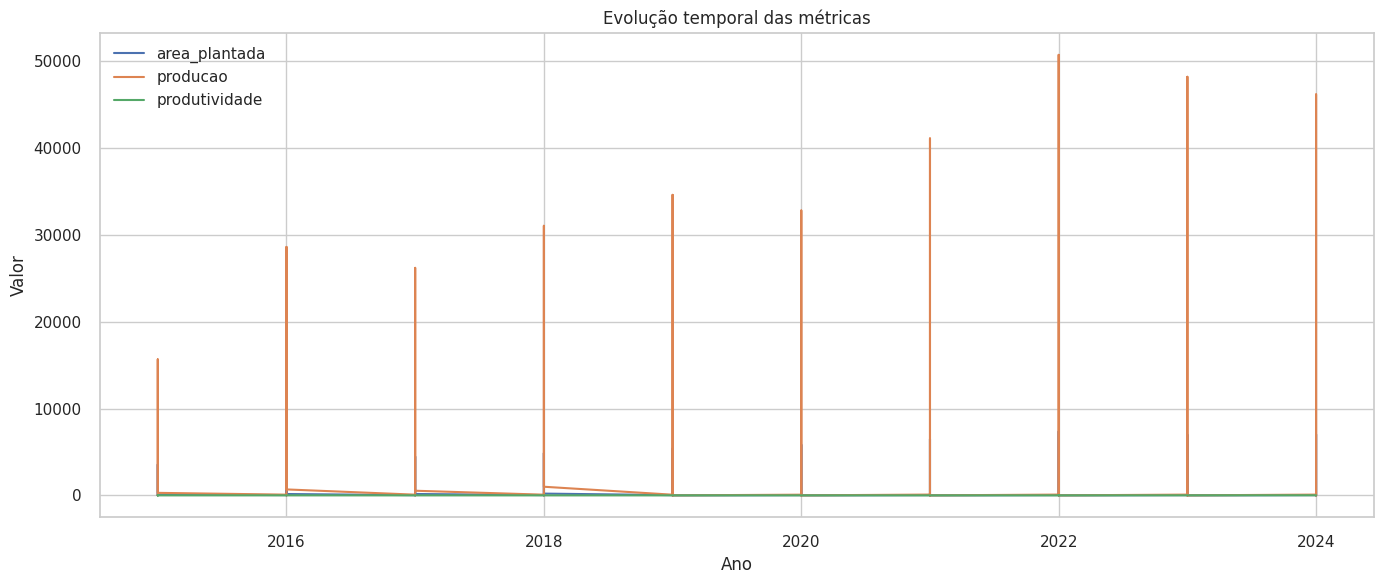

In [111]:
# Séries temporais geral
print("\nEvolução temporal das métricas:")
plt.figure(figsize=(14, 6))

# Use 'primeiro_ano' se existir, caso contrário use 'ano'
ano_coluna = 'primeiro_ano' if 'primeiro_ano' in df_milho.columns else 'ano'

for coluna in colunas_numericas:
    plt.plot(df_milho[ano_coluna], df_milho[coluna], label=coluna)

plt.title('Evolução temporal das métricas')
plt.xlabel('Ano')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Evolução temporal das métricas (2015 em diante):

Colunas de df_milho antes da conversão:
Index(['ano_agricola', 'primeiro_ano', 'segundo_ano', 'safra', 'uf', 'produto',
       'area_plantada', 'producao', 'produtividade'],
      dtype='object')
Tipo de dado de primeiro_ano: int64
Quantidade de linhas de 2015 em diante: 661


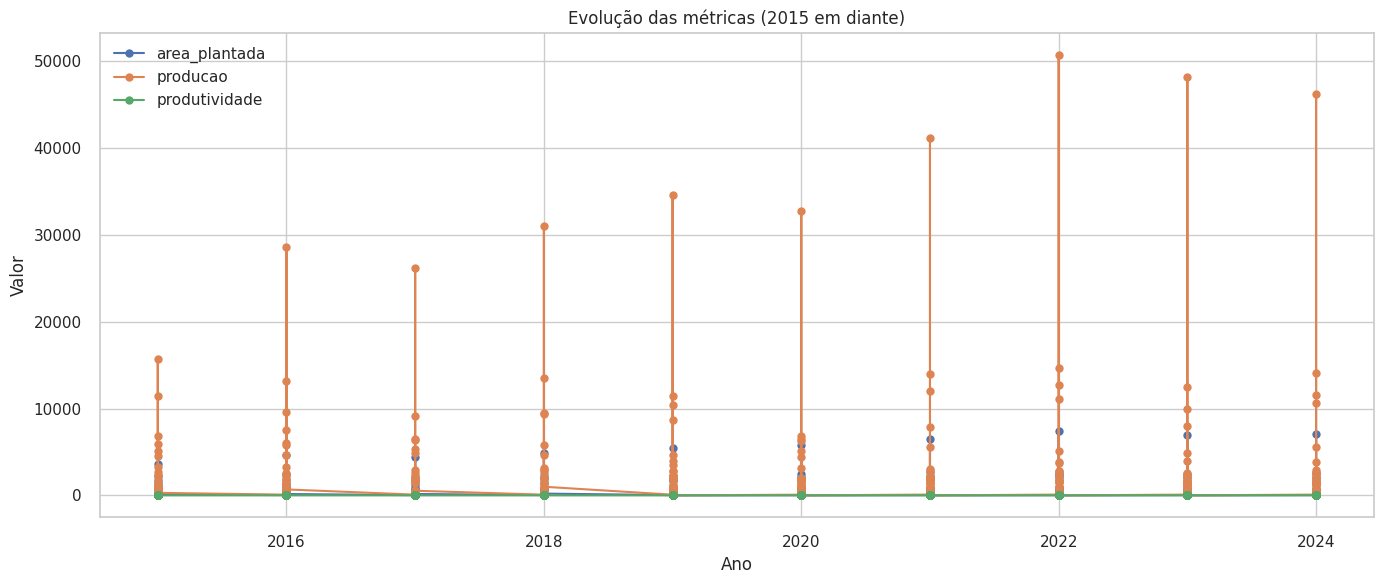

In [112]:
# Séries temporais de 2015 em diante
print("\nEvolução temporal das métricas (2015 em diante):")

# Depuração: Verificar colunas e tipo de dado
print("\nColunas de df_milho antes da conversão:")
print(df_milho.columns)
if 'primeiro_ano' in df_milho.columns:
    print(f"Tipo de dado de primeiro_ano: {df_milho['primeiro_ano'].dtype}")
else:
    print("Aviso: A coluna 'primeiro_ano' não foi encontrada.")

# Corrigir a coluna de ano se necessário
ano_coluna = 'primeiro_ano' if 'primeiro_ano' in df_milho.columns else 'ano'
df_milho[ano_coluna] = pd.to_numeric(df_milho[ano_coluna], errors='coerce')

df_2015_em_diante = df_milho[df_milho[ano_coluna] >= 2015].copy()

print(f"Quantidade de linhas de 2015 em diante: {df_2015_em_diante.shape[0]}")

# Depuração: Verificar se o DataFrame está vazio
if df_2015_em_diante.empty:
    print("DataFrame df_2015_em_diante está vazio!")
else:
    plt.figure(figsize=(14, 6))
    for coluna in colunas_numericas:
        plt.plot(df_2015_em_diante[ano_coluna], df_2015_em_diante[coluna], marker='o', label=coluna)
    plt.title('Evolução das métricas (2015 em diante)')
    plt.xlabel('Ano')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Boxplots - Comparação de distribuição entre variáveis (escalas separadas):


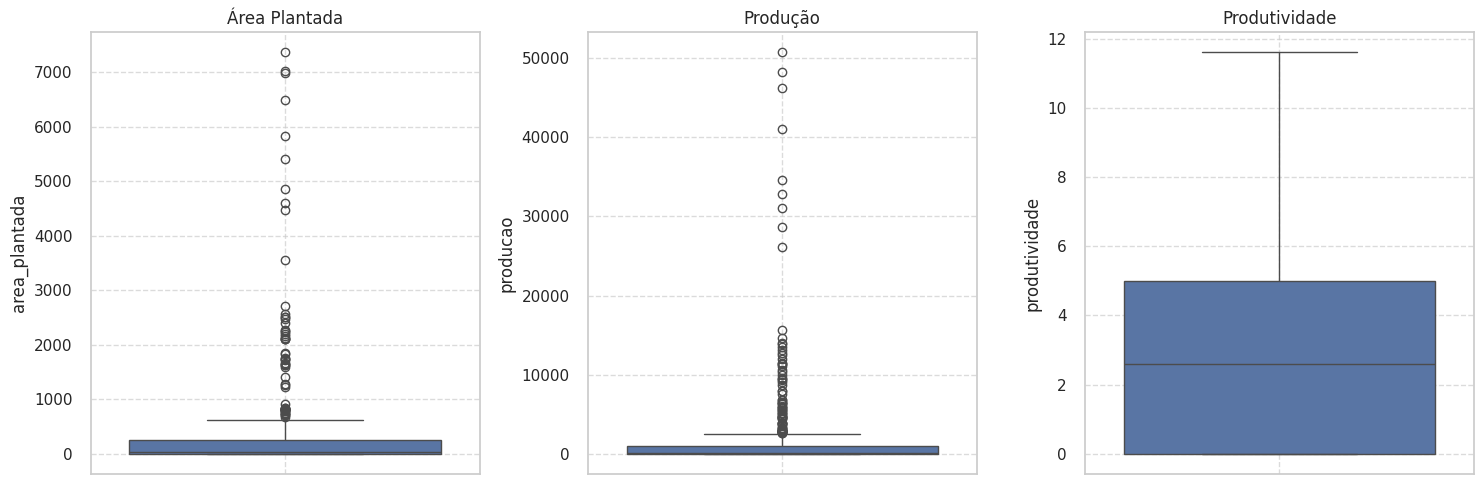

In [113]:
# Comparação de variáveis (boxplots)
print("\nBoxplots - Comparação de distribuição entre variáveis (escalas separadas):")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_milho['area_plantada'])
plt.title('Área Plantada')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 3, 2)
sns.boxplot(y=df_milho['producao'])
plt.title('Produção')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 3, 3)
sns.boxplot(y=df_milho['produtividade'])
plt.title('Produtividade')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Boxplots - Distribuição normalizada para comparação entre variáveis:


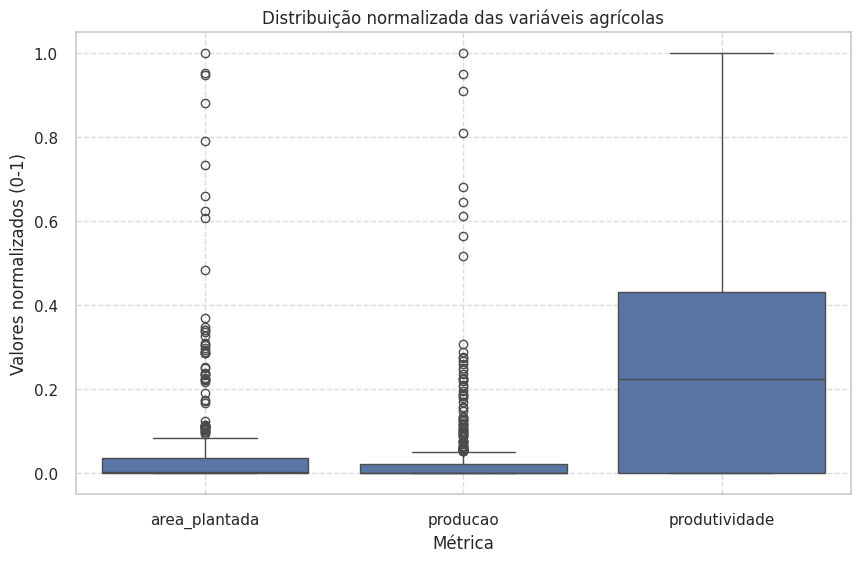

In [114]:
# Boxplots normalizados para comparação direta
print("\nBoxplots - Distribuição normalizada para comparação entre variáveis:")
plt.figure(figsize=(10, 6))

# Use 'primeiro_ano' se existir, caso contrário use 'ano'
ano_coluna = 'primeiro_ano' if 'primeiro_ano' in df_milho.columns else 'ano'

df_melt = df_milho.melt(id_vars=ano_coluna, value_vars=colunas_numericas,
                        var_name='Métrica', value_name='Valor')

df_norm = df_milho.copy()
for coluna in colunas_numericas:
    df_norm[coluna] = (df_milho[coluna] - df_milho[coluna].min()) / (df_milho[coluna].max() - df_milho[coluna].min())

df_melt_norm = df_norm.melt(id_vars=ano_coluna, value_vars=colunas_numericas,
                            var_name='Métrica', value_name='Valor Normalizado')

sns.boxplot(x='Métrica', y='Valor Normalizado', data=df_melt_norm)
plt.title('Distribuição normalizada das variáveis agrícolas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylabel('Valores normalizados (0-1)')
plt.show()



Dispersão - Relações entre variáveis:


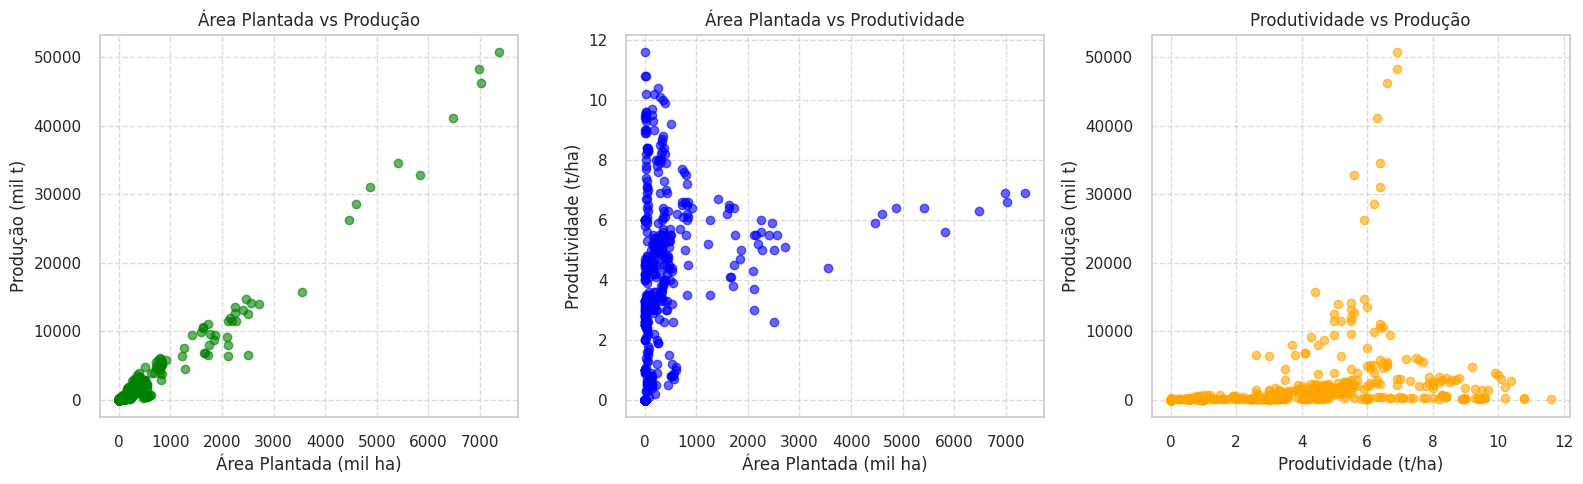

In [115]:
# Relações entre variáveis (dispersão)
print("\nDispersão - Relações entre variáveis:")
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.scatter(df_milho['area_plantada'], df_milho['producao'], alpha=0.6, color='green')
plt.title('Área Plantada vs Produção')
plt.xlabel('Área Plantada (mil ha)')
plt.ylabel('Produção (mil t)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 3, 2)
plt.scatter(df_milho['area_plantada'], df_milho['produtividade'], alpha=0.6, color='blue')
plt.title('Área Plantada vs Produtividade')
plt.xlabel('Área Plantada (mil ha)')
plt.ylabel('Produtividade (t/ha)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 3, 3)
plt.scatter(df_milho['produtividade'], df_milho['producao'], alpha=0.6, color='orange')
plt.title('Produtividade vs Produção')
plt.xlabel('Produtividade (t/ha)')
plt.ylabel('Produção (mil t)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



Boxplots - Evolução por safra:


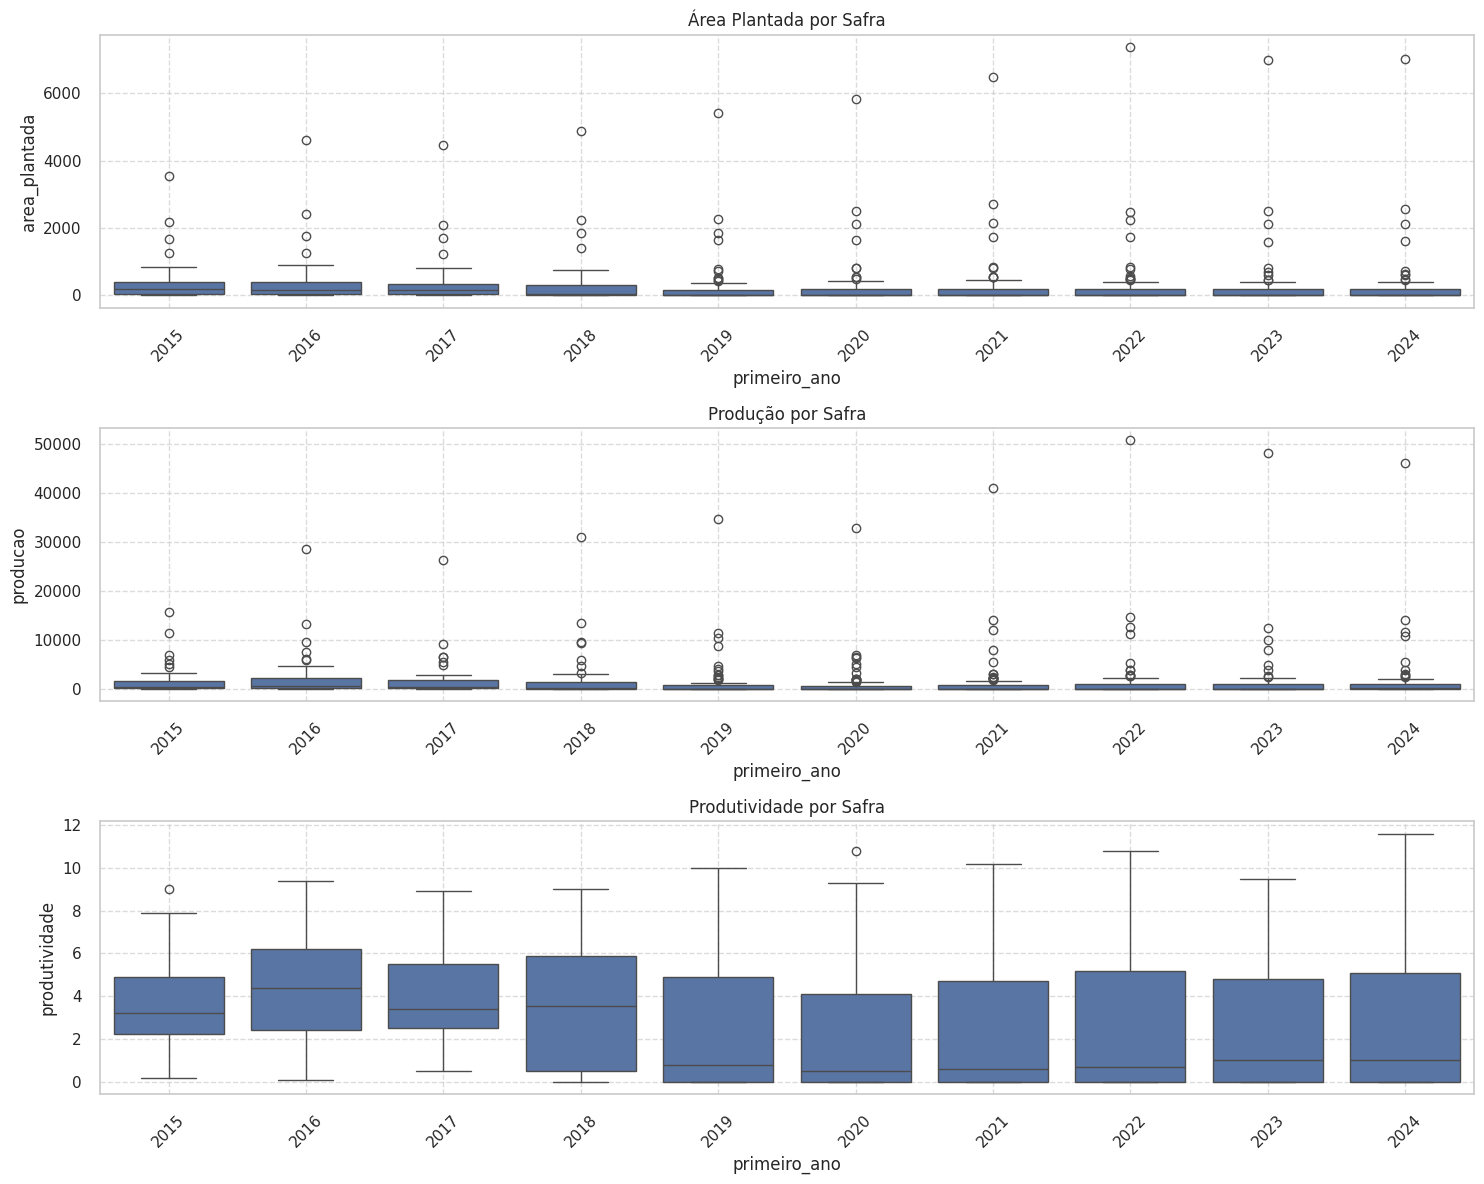

In [116]:
# Boxplots agrupados por safra
print("\nBoxplots - Evolução por safra:")
plt.figure(figsize=(15, 12))

# Use 'primeiro_ano' se existir, caso contrário use 'ano'
ano_coluna = 'primeiro_ano' if 'primeiro_ano' in df_milho.columns else 'ano'

plt.subplot(3, 1, 1)
sns.boxplot(x=ano_coluna, y='area_plantada', data=df_milho)
plt.title('Área Plantada por Safra')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.subplot(3, 1, 2)
sns.boxplot(x=ano_coluna, y='producao', data=df_milho)
plt.title('Produção por Safra')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.subplot(3, 1, 3)
sns.boxplot(x=ano_coluna, y='produtividade', data=df_milho)
plt.title('Produtividade por Safra')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Dados Google Earth

In [68]:
# Acessas as imagens no Google Earth
# Instalar pacotes necessários
!pip install earthengine-api geemap

# Importar bibliotecas
import ee
import geemap
import os
from google.colab import files
import pandas as pd
import time


In [69]:
# Autenticar e inicializar o Earth Engine
ee.Authenticate()
ee.Initialize(project="pipoca-452815")

# Definir área de interesse: Sorriso-MT
sorriso = ee.Geometry.Point(-55.71, -12.55).buffer(30000)  # 30km de buffer

# Definir período de uma safra completa
start_date = '2023-10-01'
end_date = '2024-04-30'

# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Definir pasta no Drive
drive_folder = "EarthEngine_Exports_Mensal"  # Nome da pasta para imagens mensais

# Função para calcular o NDVI
def calculate_ndvi(image):
    nir = image.select('B8')
    red = image.select('B4')
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    return image.addBands(ndvi)

# Função para exportar para o Drive (modificada para incluir ano e mês)
def export_monthly_to_drive(image, name_prefix, year, month, region, scale=30):
    month_str = f"{month:02d}"
    file_name = f"{name_prefix}_{year}_{month_str}"
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=file_name,
        folder=drive_folder,
        fileNamePrefix=file_name,
        region=region.getInfo()['coordinates'],
        scale=scale,
        maxPixels=1e9
    )
    task.start()
    print(f"Exportando {file_name} para o Google Drive...")
    return task

# Criar lista de períodos mensais
date_range = pd.date_range(start=start_date, end=end_date, freq='MS')

# Iterar sobre os meses e exportar as imagens
for date in date_range:
    year = date.year
    month = date.month
    start_month = f'{year}-{month:02d}-01'
    end_month = pd.to_datetime(start_month) + pd.offsets.MonthEnd(0)
    end_month_str = end_month.strftime('%Y-%m-%d')

    # Obter coleção Sentinel-2 para o mês atual
    s2_monthly = ee.ImageCollection('COPERNICUS/S2_SR') \
        .filterDate(start_month, end_month_str) \
        .filterBounds(sorriso) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .select(['B2', 'B3', 'B4', 'B8']) \
        .median()  # Mediana para remover nuvens

    # Calcular NDVI para o mês atual
    ndvi_monthly = s2_monthly.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # Exportar RGB para o mês atual
    export_monthly_to_drive(
        s2_monthly.select(['B4', 'B3', 'B2']).divide(3000).multiply(255).byte(),
        "sorriso_rgb",
        year,
        month,
        sorriso,
        scale=30
    )

    # Exportar NDVI para o mês atual
    export_monthly_to_drive(
        ndvi_monthly,
        "sorriso_ndvi",
        year,
        month,
        sorriso,
        scale=30
    )

print("\nImagens mensais estão sendo exportadas para seu Google Drive.")
print("Este processo pode levar um tempo considerável, dependendo do número de meses e da área.")
print("As imagens estarão na pasta", drive_folder)
print("Você pode verificar o progresso em: https://code.earthengine.google.com/tasks")
print("Quando as tarefas estiverem concluídas, você poderá acessar os arquivos no seu Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Exportando sorriso_rgb_2023_10 para o Google Drive...
Exportando sorriso_ndvi_2023_10 para o Google Drive...
Exportando sorriso_rgb_2023_11 para o Google Drive...
Exportando sorriso_ndvi_2023_11 para o Google Drive...
Exportando sorriso_rgb_2023_12 para o Google Drive...
Exportando sorriso_ndvi_2023_12 para o Google Drive...
Exportando sorriso_rgb_2024_01 para o Google Drive...
Exportando sorriso_ndvi_2024_01 para o Google Drive...
Exportando sorriso_rgb_2024_02 para o Google Drive...
Exportando sorriso_ndvi_2024_02 para o Google Drive...
Exportando sorriso_rgb_2024_03 para o Google Drive...
Exportando sorriso_ndvi_2024_03 para o Google Drive...
Exportando sorriso_rgb_2024_04 para o Google Drive...
Exportando sorriso_ndvi_2024_04 para o Google Drive...

Imagens mensais estão sendo exportadas para seu Google Drive.
Este processo pode levar um tempo consideráve

In [72]:
# Google Earth - Transformar as imagens em numeros
# Autenticar e inicializar o Earth Engine
ee.Authenticate()
ee.Initialize(project="pipoca-452815")

# Definir região de interesse (Sorriso, Mato Grosso)
sorriso = ee.Geometry.Point([-55.71, -12.55])  # Coordenadas aproximadas

# Definir o período de tempo
start_date = '2015-01-01'
end_date = '2024-03-31'

# Criar uma lista de todos os meses no período
def generate_monthly_dates(start, end):
    start_date = pd.to_datetime(start)
    end_date = pd.to_datetime(end)
    dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    # Removed getInfo() call and directly create ee.Date objects
    ee_dates = ee.List(dates.strftime('%Y-%m-%d').tolist()).map(lambda date_str: ee.Date(date_str))
    # Use get('year') and get('month') within a server-side function
    # Corrected to directly create FeatureCollection from the mapped list
    return ee.FeatureCollection(ee_dates.map(lambda date: ee.Feature(None, {'year': ee.Date(date).get('year'), 'month': ee.Date(date).get('month')})))


# Coleção de imagens Landsat (exemplo, escolha a coleção que melhor se adapta à sua necessidade)
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(sorriso) \
    .filterDate(start_date, end_date)

# Função para calcular o NDVI
def calculate_ndvi(image):
    nir = image.select('SR_B5')  # Banda NIR para Landsat 8
    red = image.select('SR_B4')  # Banda Vermelha para Landsat 8
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    return image.addBands(ndvi)

# Aplica a função para calcular o NDVI em toda a coleção
ndvi_collection = landsat.map(calculate_ndvi)

# Função para reduzir a imagem para a média do NDVI na região
def reduce_monthly_ndvi(year_month):
    year = ee.Number(year_month.get('year'))
    month = ee.Number(year_month.get('month'))
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')

    monthly_image = ndvi_collection.filterDate(start, end).mean()

    if monthly_image:
        mean_ndvi = monthly_image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=sorriso,
            scale=30,  # Ajuste a escala conforme a resolução da imagem
            maxPixels=1e9
        ).get('NDVI')
        return ee.Feature(None, {'year': year, 'month': month, 'mean_ndvi': mean_ndvi})
    else:
        return ee.Feature(None, {'year': year, 'month': month, 'mean_ndvi': None})

monthly_dates = generate_monthly_dates(start_date, end_date)

# Mapeamento da função de redução sobre a lista de meses
monthly_ndvi_features = monthly_dates.map(reduce_monthly_ndvi) # Modified: monthly_dates is already a FeatureCollection

# Converter os resultados do Earth Engine para um DataFrame pandas
def ee_to_pandas(data):
    features = data.getInfo()['features']
    dict_list = []
    for f in features:
        dict_list.append(f['properties'])
    return pd.DataFrame(dict_list)

# Obter os resultados e converção para pandas
monthly_ndvi_df = ee_to_pandas(monthly_ndvi_features)

# Calcular média anual de NDVI
annual_ndvi_df = monthly_ndvi_df.groupby('year')['mean_ndvi'].mean().reset_index()
annual_ndvi_df = annual_ndvi_df.rename(columns={'mean_ndvi': 'annual_mean_ndvi'})

# Merge da médiaanual
monthly_ndvi_df = pd.merge(monthly_ndvi_df, annual_ndvi_df, on='year', how='left')


# Imprimit o dataframe resultante
print(monthly_ndvi_df)

# Salvar dados processados
processed_path = os.path.join('dados_processados', 'ndvi_mensalGoogle.csv') # Changed this line to save in 'dados_processados'
monthly_ndvi_df.to_csv(processed_path, index=False)
print(f"DataFrame NDVI mensal Google Earth em: {processed_path}")

     mean_ndvi  month  year  annual_mean_ndvi
0     0.077605      1  2015          0.051384
1     0.097902      2  2015          0.051384
2     0.042416      3  2015          0.051384
3     0.082564      4  2015          0.051384
4     0.069358      5  2015          0.051384
..         ...    ...   ...               ...
106   0.046528     11  2023          0.072998
107   0.103179     12  2023          0.072998
108   0.047424      1  2024          0.057194
109   0.047743      2  2024          0.057194
110   0.076415      3  2024          0.057194

[111 rows x 4 columns]
DataFrame NDVI mensal Google Earth em: dados_processados/ndvi_mensalGoogle.csv


# Etapa 2 – Extração de Informações Relevantes:

*   Definir variáveis-chave a serem utilizadas no modelo, a partir da análise
exploratória dos dados.
*   Analisar a relação entre NDVI e produtividade agrícola, identificando os períodos críticos de crescimento da cultura.
*   Aplicar técnicas de segmentação para destacar áreas específicas de cultivo na imagem de satélite.

--- Etapa B: Consolidação e Análise Focada ---
[OK] Arquivos CSV processados carregados.

--- Preparando DataFrames para Merge ---
[OK] df_clima preparado (ANO, MES, DATA).
[OK] df_satveg_mensal preparado (ANO, MES, NDVI_satveg_mensal).
[INFO] Colunas renomeadas em df_ndvi_google: {'year': 'ANO', 'month': 'MES', 'mean_ndvi': 'NDVI_google_mensal'}
[OK] df_ndvi_google preparado. Colunas: ['ANO', 'MES', 'NDVI_google_mensal', 'annual_mean_ndvi']
[OK] df_prod_anual preparado (ANO, Produtividade_Anual).
     Primeiras linhas df_prod_anual:
      ANO  Produtividade_Anual
0    2015                  2.4
39   2016                  2.3
80   2017                  2.6
121  2018                  2.4
175  2019                  2.5

--- Realizando Merges para Consolidar ---

Estratégia de Merge 1: Mantendo granularidade do Clima...
  * Iniciando com df_clima.
  + Merge com SatVeg Mensal realizado.
  + Merge com NDVI Google realizado.
  + Merge com Produtividade Anual realizado.

[INFO] DataFrame Conso

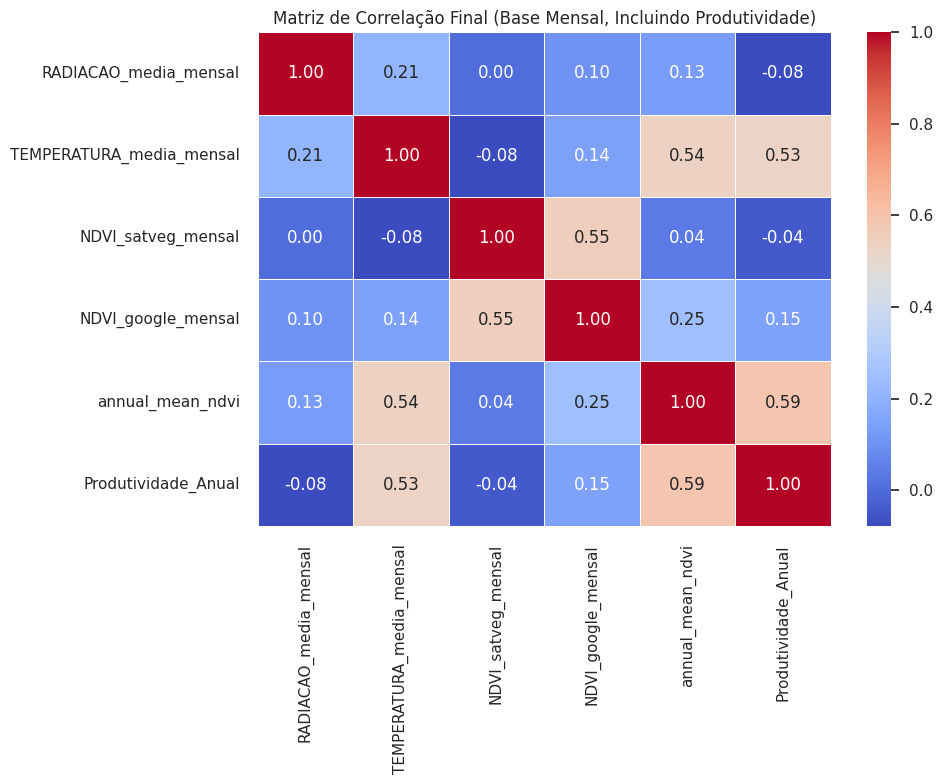


**Análise da Correlação com Produtividade_Anual:**
Produtividade_Anual         1.000000
annual_mean_ndvi            0.588557
TEMPERATURA_media_mensal    0.529952
NDVI_google_mensal          0.146424
NDVI_satveg_mensal         -0.043709
RADIACAO_media_mensal      -0.075441
Name: Produtividade_Anual, dtype: float64

  -> Variáveis com maior correlação (positiva ou negativa) com a produtividade anual são candidatas a serem 'chave'.
  -> Lembre-se: Correlação não implica causalidade.

**Variáveis-Chave Sugeridas (a confirmar com análise):**
  - Produtividade_Anual (Variável Alvo)
  - NDVI_google_mensal (ou métrica anual/pico derivada dela)
  - TEMPERATURA_media_mensal (ou métrica anual/ciclo derivada dela)
  - RADIACAO_media_mensal (ou métrica anual/ciclo derivada dela)
  - ANO (para capturar tendências ou efeitos anuais não explicados)

5.2. Relação NDVI-Produtividade e Períodos Críticos...


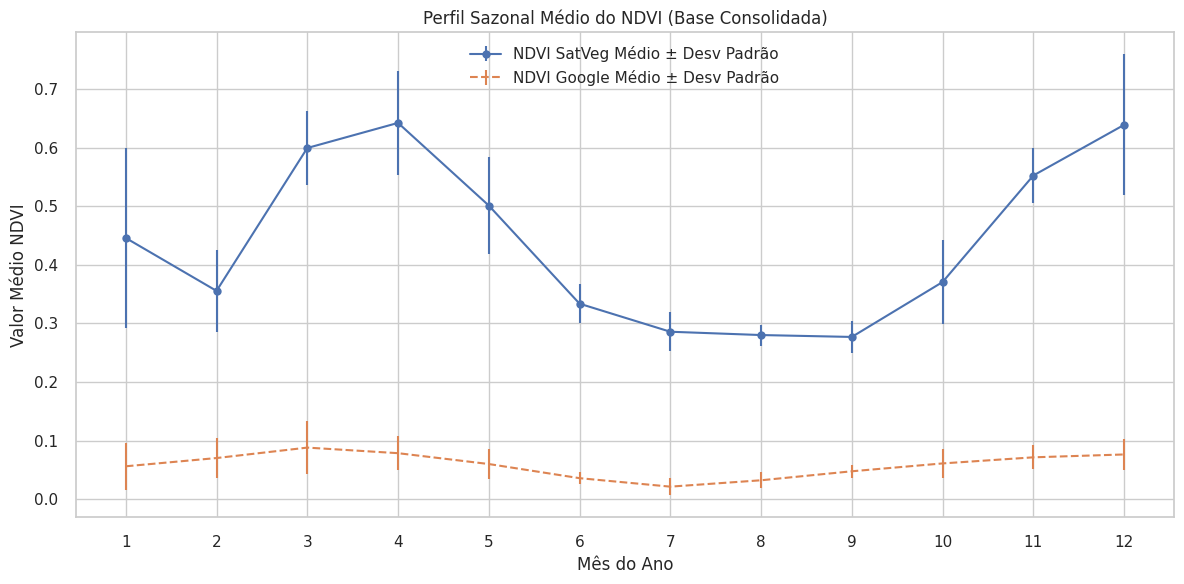


**Identificação de Períodos Críticos (Fenologia Média):**
  Observe o gráfico acima para identificar os meses com maior NDVI médio.
  - Pico médio do NDVI Google ocorre no Mês: 3 (Valor médio: 0.088)
  - Meses próximos a este pico são considerados críticos para o desenvolvimento vegetativo.


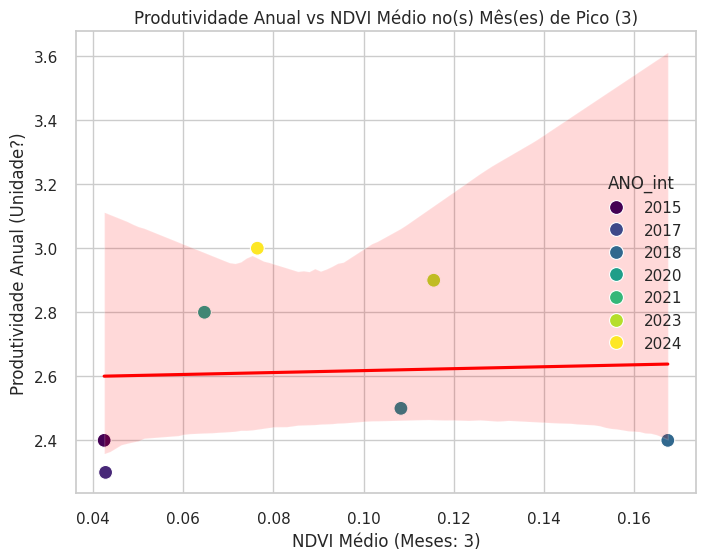


  -> Correlação entre Produtividade Anual e NDVI Médio no Pico: 0.049
     Uma correlação positiva aqui sugere que maior vigor vegetativo no período crítico está associado a maior produtividade.

5.3. Segmentação (Identificação de Fases Fenológicas)...
  A 'segmentação' neste contexto refere-se à identificação das fases de crescimento da cultura observando a curva do NDVI ao longo do ano (Gráfico de Perfil Sazonal Médio):
    - **Fase 1: Início/Emergência:** Meses onde o NDVI começa a subir rapidamente (após um período de baixa).
    - **Fase 2: Desenvolvimento/Pico Vegetativo:** Meses onde o NDVI atinge o valor máximo.
    - **Fase 3: Maturação/Senescência:** Meses onde o NDVI começa a cair consistentemente.
    - **Fase 4: Entressafra/Repouso:** Meses com NDVI baixo e estável.
  -> Identifique visualmente esses meses no gráfico 'Perfil Sazonal Médio do NDVI' gerado acima.
  (Segmentação de imagem para delimitar áreas de cultivo é um processo diferente e mais complexo, não abordado a

In [150]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# --- 1. Carregar os 4 Arquivos Processados ---
print("--- Etapa 2: Consolidação e Análise Focada ---")
processed_folder = 'dados_processados'
try:
    # Carregar os arquivos CSV gerados na etapa 1
    df_clima = pd.read_csv(os.path.join(processed_folder, 'clima_consolidado.csv'))
    df_satveg = pd.read_csv(os.path.join(processed_folder, 'satveg_processado.csv'))
    df_milho = pd.read_csv(os.path.join(processed_folder, 'milho.csv'))
    df_ndvi_google = pd.read_csv(os.path.join(processed_folder, 'ndvi_mensalGoogle.csv'))
    print("[OK] Arquivos CSV processados carregados.")
except FileNotFoundError as e:
    print(f"[ERRO CRÍTICO] Arquivo CSV processado não encontrado: {e}.")
    print("  Verifique se a Etapa A (pré-processamento individual) foi executada corretamente")
    print(f"  e se os arquivos estão na pasta '{processed_folder}'.")

except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao carregar arquivos CSV processados: {e}")


# --- 2. Preparar DataFrames para Merge ---
# Esta seção garante que os DataFrames carregados tenham as colunas necessárias
# e os tipos de dados corretos para a junção (merge).
print("\n--- Preparando DataFrames para Merge ---")

# Preparar Clima (Garantir Colunas ANO, MES, DATA datetime)
try:
    if 'df_clima' in locals() and isinstance(df_clima, pd.DataFrame):
        if 'DATA' in df_clima.columns:
            df_clima['DATA'] = pd.to_datetime(df_clima['DATA'], errors='coerce')
        # Garante que ANO e MES existam, derivando de DATA se necessário
        if 'ANO' not in df_clima.columns and 'DATA' in df_clima.columns and pd.api.types.is_datetime64_any_dtype(df_clima['DATA']):
            df_clima['ANO'] = df_clima['DATA'].dt.year
        if 'MES' not in df_clima.columns and 'DATA' in df_clima.columns and pd.api.types.is_datetime64_any_dtype(df_clima['DATA']):
            df_clima['MES'] = df_clima['DATA'].dt.month
        # Tenta converter ANO e MES para Int64 (permite nulos)
        if 'ANO' in df_clima.columns: df_clima['ANO'] = pd.to_numeric(df_clima['ANO'], errors='coerce').astype('Int64')
        if 'MES' in df_clima.columns: df_clima['MES'] = pd.to_numeric(df_clima['MES'], errors='coerce').astype('Int64')
        # Verifica se as colunas essenciais existem após a preparação
        if 'ANO' in df_clima.columns and 'MES' in df_clima.columns:
             print("[OK] df_clima preparado (ANO, MES, DATA).")
        else:
             print("[ERRO] Colunas ANO ou MES não puderam ser criadas/encontradas em df_clima.")
             df_clima = None # Invalida se não tiver ANO/MES
    else:
        print("[ERRO] df_clima não carregado ou não é um DataFrame.")
        df_clima = None
except Exception as e:
    print(f"[ERRO] Falha geral ao preparar df_clima: {e}")
    df_clima = None


# Preparar SatVeg Mensal (df_satveg_mensal)
df_satveg_mensal = None # Inicializa como None
try:
    if 'df_satveg' in locals() and isinstance(df_satveg, pd.DataFrame):
        # Verifica se as colunas necessárias existem
        if 'AnoMes' in df_satveg.columns and 'NDVI_media_mensal' in df_satveg.columns:
            df_satveg['AnoMes'] = df_satveg['AnoMes'].astype(str)
            # Isola as colunas, remove duplicatas mensais
            df_satveg_mensal = df_satveg[['AnoMes', 'NDVI_media_mensal']].drop_duplicates(subset=['AnoMes']).copy()
            # Renomeia a coluna NDVI
            df_satveg_mensal = df_satveg_mensal.rename(columns={'NDVI_media_mensal': 'NDVI_satveg_mensal'})
            # Tenta extrair ANO e MES da coluna AnoMes
            try:
                 df_satveg_mensal[['ANO', 'MES']] = df_satveg_mensal['AnoMes'].str.split('-', expand=True).astype(int)
                 # Seleciona apenas as colunas finais
                 df_satveg_mensal = df_satveg_mensal[['ANO', 'MES', 'NDVI_satveg_mensal']]
                 print("[OK] df_satveg_mensal preparado (ANO, MES, NDVI_satveg_mensal).")
            except Exception as e_inner:
                 print(f"[AVISO] Não foi possível extrair ANO/MES de AnoMes em df_satveg_mensal: {e_inner}")
                 df_satveg_mensal = None # Invalida se não conseguir ANO/MES
        else:
            print("[ERRO] Colunas 'AnoMes' ou 'NDVI_media_mensal' não encontradas em df_satveg.")
    else:
         print("[ERRO] df_satveg não carregado ou não é um DataFrame.")
except Exception as e:
    print(f"[ERRO] Falha geral ao preparar df_satveg: {e}")


# Preparar NDVI Google (df_ndvi_google)
try:
    if 'df_ndvi_google' in locals() and isinstance(df_ndvi_google, pd.DataFrame):
        # Mapa para renomear colunas (original -> novo)
        rename_map_google = {'year': 'ANO', 'month': 'MES', 'mean_ndvi': 'NDVI_google_mensal'}
        # Renomeia apenas as colunas que existem com o nome original
        cols_a_renomear = {k: v for k, v in rename_map_google.items() if k in df_ndvi_google.columns}
        if cols_a_renomear:
             df_ndvi_google = df_ndvi_google.rename(columns=cols_a_renomear)
             print(f"[INFO] Colunas renomeadas em df_ndvi_google: {cols_a_renomear}")

        # Define as colunas que queremos manter no final
        cols_finais = ['ANO', 'MES', 'NDVI_google_mensal', 'annual_mean_ndvi']
        # Seleciona apenas as colunas finais que existem no DataFrame
        cols_presentes = [col for col in cols_finais if col in df_ndvi_google.columns]
        if 'ANO' in cols_presentes and 'MES' in cols_presentes: # Verifica se as chaves de merge existem
             df_ndvi_google = df_ndvi_google[cols_presentes].copy()
             # Tenta converter ANO e MES para Int64
             if 'ANO' in df_ndvi_google.columns: df_ndvi_google['ANO'] = pd.to_numeric(df_ndvi_google['ANO'], errors='coerce').astype('Int64')
             if 'MES' in df_ndvi_google.columns: df_ndvi_google['MES'] = pd.to_numeric(df_ndvi_google['MES'], errors='coerce').astype('Int64')
             print(f"[OK] df_ndvi_google preparado. Colunas: {df_ndvi_google.columns.tolist()}")
        else:
             print("[ERRO] Colunas ANO ou MES não encontradas em df_ndvi_google após preparação.")
             df_ndvi_google = None # Invalida se não tiver ANO/MES
    else:
        print("[ERRO] df_ndvi_google não carregado/definido.")
except Exception as e:
    print(f"[ERRO] Falha geral ao preparar df_ndvi_google: {e}")
    df_ndvi_google = None


# Preparar Produtividade Anual (df_prod_anual)
df_prod_anual = None # Inicializa como None
coluna_produtividade = 'produtividade' # Confirmado pelo usuário
coluna_ano_milho = 'primeiro_ano' # Confirmado pelo usuário
try:
    # Verifica se df_milho existe e tem as colunas necessárias
    if 'df_milho' in locals() and isinstance(df_milho, pd.DataFrame) and coluna_produtividade in df_milho.columns and coluna_ano_milho in df_milho.columns:
        # Seleciona as colunas de ano e produtividade
        df_prod_anual = df_milho[[coluna_ano_milho, coluna_produtividade]].copy()
        # Converte ano para Int64 (permite NaN) e produtividade para numérico
        df_prod_anual[coluna_ano_milho] = pd.to_numeric(df_prod_anual[coluna_ano_milho], errors='coerce').astype('Int64')
        df_prod_anual[coluna_produtividade] = pd.to_numeric(df_prod_anual[coluna_produtividade], errors='coerce')
        # Remove linhas onde a conversão falhou (resultou em NaN)
        df_prod_anual = df_prod_anual.dropna(subset=[coluna_ano_milho, coluna_produtividade])
        # Remove anos duplicados, mantendo o primeiro registro encontrado
        df_prod_anual = df_prod_anual.drop_duplicates(subset=[coluna_ano_milho], keep='first')
        # Renomeia as colunas para o padrão ('ANO', 'Produtividade_Anual')
        df_prod_anual = df_prod_anual.rename(columns={coluna_produtividade: 'Produtividade_Anual', coluna_ano_milho: 'ANO'})

        # Verifica se o DataFrame resultante não está vazio
        if not df_prod_anual.empty:
             print("[OK] df_prod_anual preparado (ANO, Produtividade_Anual).")
             print("     Primeiras linhas df_prod_anual:")
             print(df_prod_anual.head())
        else:
             print("[AVISO] df_prod_anual ficou vazio após limpeza/remoção de duplicatas.")
             df_prod_anual = None # Invalida se vazio
    else:
        # Informa quais colunas estão faltando, se for o caso
        missing_cols = []
        if 'df_milho' not in locals() or not isinstance(df_milho, pd.DataFrame):
            missing_cols.append("df_milho não definido")
        else:
            if coluna_produtividade not in df_milho.columns: missing_cols.append(f"'{coluna_produtividade}'")
            if coluna_ano_milho not in df_milho.columns: missing_cols.append(f"'{coluna_ano_milho}'")
        print(f"[ERRO] Não foi possível preparar df_prod_anual. Colunas ausentes/problemas: {', '.join(missing_cols)}.")
except Exception as e:
    print(f"[ERRO] Falha geral ao preparar df_prod_anual: {e}")
    df_prod_anual = None


# --- 3. Realizar Merges para Consolidação ---
print("\n--- Realizando Merges para Consolidar ---")
# Iremos criar as duas versões: diária/horária e mensal agregada.

# --- ESTRATÉGIA 1: Manter Granularidade do Clima (Horária/Diária) ---
print("\nEstratégia de Merge 1: Mantendo granularidade do Clima...")
df_consolidado_diario = None # Inicializa como None
try:
    # Só prossegue se df_clima estiver válido (com ANO e MES)
    if 'df_clima' in locals() and isinstance(df_clima, pd.DataFrame) and 'ANO' in df_clima.columns and 'MES' in df_clima.columns:
        df_consolidado_diario = df_clima.copy() # Começa com o mais granular
        print("  * Iniciando com df_clima.")

        # Merge com SatVeg Mensal (usando ANO e MES)
        if df_satveg_mensal is not None and isinstance(df_satveg_mensal, pd.DataFrame):
             df_consolidado_diario = pd.merge(df_consolidado_diario, df_satveg_mensal[['ANO', 'MES', 'NDVI_satveg_mensal']], on=['ANO', 'MES'], how='left')
             print("  + Merge com SatVeg Mensal realizado.")
        else:
             print("  - Pular Merge com SatVeg (df_satveg_mensal inválido).")

        # Merge com NDVI Google (usando ANO e MES)
        if 'df_ndvi_google' in locals() and isinstance(df_ndvi_google, pd.DataFrame):
             df_consolidado_diario = pd.merge(df_consolidado_diario, df_ndvi_google, on=['ANO', 'MES'], how='left')
             print("  + Merge com NDVI Google realizado.")
        else:
             print("  - Pular Merge com NDVI Google (df_ndvi_google inválido).")

        # Merge com Produtividade Anual (usando ANO)
        if df_prod_anual is not None and isinstance(df_prod_anual, pd.DataFrame):
             df_consolidado_diario = pd.merge(df_consolidado_diario, df_prod_anual, on='ANO', how='left')
             print("  + Merge com Produtividade Anual realizado.")
        else:
             print("  - Pular Merge com Produtividade (df_prod_anual inválido).")

        print("\n[INFO] DataFrame Consolidado (granularidade diária/horária) - Estrutura:")
        df_consolidado_diario.info()
        # print(df_consolidado_diario.head()) # Descomente para ver as primeiras linhas
    else:
        print("[ERRO] df_clima inválido ou sem colunas ANO/MES. Base diária não pode ser criada.")

except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao criar df_consolidado_diario: {e}")
    df_consolidado_diario = None # Garante que está None em caso de erro


# --- ESTRATÉGIA 2: Agregar Mensalmente ---
print("\nEstratégia de Merge 2: Agregando dados mensalmente...")
df_consolidado_mensal = None # Inicializa como None
try:
    # Só prossegue se df_clima estiver válido (com ANO e MES)
    if 'df_clima' in locals() and isinstance(df_clima, pd.DataFrame) and 'ANO' in df_clima.columns and 'MES' in df_clima.columns:
        # Agrega Clima por ANO e MES, calculando a média
        df_clima_mensal_agg = df_clima.groupby(['ANO', 'MES']).agg(
            RADIACAO_media_mensal=('RADIACAO', 'mean'),
            TEMPERATURA_media_mensal=('TEMPERATURA', 'mean')
            # Adicione outras métricas climáticas mensais aqui se desejar
        ).reset_index()
        print("  * Clima agregado mensalmente.")

        # Começa a base mensal com o clima agregado
        df_consolidado_mensal = df_clima_mensal_agg.copy()

        # Merge com SatVeg Mensal
        if df_satveg_mensal is not None and isinstance(df_satveg_mensal, pd.DataFrame):
             df_consolidado_mensal = pd.merge(df_consolidado_mensal, df_satveg_mensal[['ANO', 'MES', 'NDVI_satveg_mensal']], on=['ANO', 'MES'], how='left')
             print("  + Merge com SatVeg Mensal realizado.")
        else:
             print("  - Pular Merge com SatVeg (df_satveg_mensal inválido).")

        # Merge com NDVI Google
        if 'df_ndvi_google' in locals() and isinstance(df_ndvi_google, pd.DataFrame):
             df_consolidado_mensal = pd.merge(df_consolidado_mensal, df_ndvi_google, on=['ANO', 'MES'], how='left')
             print("  + Merge com NDVI Google realizado.")
        else:
             print("  - Pular Merge com NDVI Google (df_ndvi_google inválido).")

        # Merge com Produtividade Anual
        if df_prod_anual is not None and isinstance(df_prod_anual, pd.DataFrame):
             df_consolidado_mensal = pd.merge(df_consolidado_mensal, df_prod_anual, on='ANO', how='left')
             print("  + Merge com Produtividade Anual realizado.")
        else:
             print("  - Pular Merge com Produtividade (df_prod_anual inválido).")

        # Ordena o resultado final por ano e mês
        df_consolidado_mensal = df_consolidado_mensal.sort_values(by=['ANO', 'MES']).reset_index(drop=True)

        print("\n[INFO] DataFrame Consolidado Mensal - Estrutura:")
        df_consolidado_mensal.info()
        print("\n[INFO] Primeiras linhas do DataFrame Consolidado Mensal (Dataset Base):") # <-- Adicionado Print
        print(df_consolidado_mensal.head()) # <-- Adicionada linha para mostrar o head()
    else:
        print("[ERRO] df_clima inválido ou sem colunas ANO/MES. Base mensal não pode ser criada.")

except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao criar df_consolidado_mensal: {e}")
    df_consolidado_mensal = None # Garante que está None em caso de erro


# --- 4. Salvar as Bases Consolidadas ---
print("\n--- Salvando Bases Consolidadas ---")
output_filename_diario = 'base_consolidada_diaria.csv'
output_filename_mensal = 'base_consolidada_mensal.csv'
output_path_diario = os.path.join(processed_folder, output_filename_diario)
output_path_mensal = os.path.join(processed_folder, output_filename_mensal)

try:
    # Salva a base diária/horária se ela foi criada com sucesso
    if 'df_consolidado_diario' in locals() and isinstance(df_consolidado_diario, pd.DataFrame):
        df_consolidado_diario.to_csv(output_path_diario, index=False)
        print(f"[OK] Base consolidada DIÁRIA salva em: {output_path_diario}")
    else:
        print(f"[AVISO] df_consolidado_diario não definido ou inválido. Arquivo '{output_filename_diario}' não salvo.")

    # Salva a base mensal se ela foi criada com sucesso
    if 'df_consolidado_mensal' in locals() and isinstance(df_consolidado_mensal, pd.DataFrame):
        df_consolidado_mensal.to_csv(output_path_mensal, index=False)
        print(f"[OK] Base consolidada MENSAL salva em: {output_path_mensal}")
    else:
        print(f"[AVISO] df_consolidado_mensal não definido ou inválido. Arquivo '{output_filename_mensal}' não salvo.")

except Exception as e:
    print(f"[ERRO] Falha ao salvar bases consolidadas: {e}")


# --- 5. Responder às Perguntas da Etapa 2 (Análise da Base Consolidada Mensal) ---
print("\n--- Respondendo Perguntas da Etapa 2 (Análise da Base Consolidada Mensal) ---")

# Verifica se a base mensal existe e é válida para prosseguir com a análise
if 'df_consolidado_mensal' not in locals() or not isinstance(df_consolidado_mensal, pd.DataFrame) or df_consolidado_mensal.empty:
    print("[ERRO] DataFrame 'df_consolidado_mensal' não está disponível ou está vazio. Análise da Etapa 2 não pode continuar.")
else:
    print("[INFO] Iniciando análise com 'df_consolidado_mensal'.")
    # --- 5.1. Variáveis-chave ---
    print("\n5.1. Identificando Variáveis-Chave...")

    # Define as colunas de interesse para correlação
    colunas_corr_prod = [
        'RADIACAO_media_mensal', 'TEMPERATURA_media_mensal',
        'NDVI_satveg_mensal', 'NDVI_google_mensal', 'annual_mean_ndvi',
        'Produtividade_Anual'
    ]
    # Filtra apenas as colunas que realmente existem no DataFrame
    colunas_corr_existentes = [col for col in colunas_corr_prod if col in df_consolidado_mensal.columns]

    # Verifica se temos pelo menos duas colunas para calcular a correlação
    if len(colunas_corr_existentes) > 1:
        # Remove linhas com valores ausentes (NaN) nas colunas selecionadas para correlação
        df_corr = df_consolidado_mensal[colunas_corr_existentes].dropna()

        # Verifica se restaram dados suficientes após remover NaNs
        if not df_corr.empty and len(df_corr) > 1:
             # Calcula a matriz de correlação
             matriz_corr_final = df_corr.corr()

             # Plota o heatmap da matriz de correlação
             plt.figure(figsize=(10, 8))
             sns.heatmap(matriz_corr_final, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
             plt.title('Matriz de Correlação Final (Base Mensal, Incluindo Produtividade)')
             plt.tight_layout()
             plt.show()

             # Analisa a correlação especificamente com a Produtividade Anual
             print("\n**Análise da Correlação com Produtividade_Anual:**")
             if 'Produtividade_Anual' in matriz_corr_final.columns:
                 # Exibe as correlações com a produtividade, ordenadas
                 print(matriz_corr_final['Produtividade_Anual'].sort_values(ascending=False))
                 print("\n  -> Variáveis com maior correlação (positiva ou negativa) com a produtividade anual são candidatas a serem 'chave'.")
                 print("  -> Lembre-se: Correlação não implica causalidade.")
             else:
                 print("  -> Coluna 'Produtividade_Anual' não encontrada na matriz para análise detalhada.")
        else:
             print("[AVISO] Não há dados suficientes após remover NaNs para calcular a matriz de correlação.")
    else:
        print("[AVISO] Não há colunas suficientes ou válidas para calcular a matriz de correlação final.")

    # Sugestão de variáveis chave com base na análise visual e de correlação (ajustar conforme resultados)
    print("\n**Variáveis-Chave Sugeridas (a confirmar com análise):**")
    print("  - Produtividade_Anual (Variável Alvo)")
    print("  - NDVI_google_mensal (ou métrica anual/pico derivada dela)")
    print("  - TEMPERATURA_media_mensal (ou métrica anual/ciclo derivada dela)")
    print("  - RADIACAO_media_mensal (ou métrica anual/ciclo derivada dela)")
    print("  - ANO (para capturar tendências ou efeitos anuais não explicados)")


    # --- 5.2. Relação NDVI-Produtividade e Períodos Críticos ---
    print("\n5.2. Relação NDVI-Produtividade e Períodos Críticos...")

    mes_pico = None # Inicializa mes_pico como None
    try:
        # Colunas NDVI a serem consideradas para o perfil
        ndvi_cols_perfil = [col for col in ['NDVI_satveg_mensal', 'NDVI_google_mensal'] if col in df_consolidado_mensal.columns]

        # Verifica se temos a coluna MES e pelo menos uma coluna NDVI
        if 'MES' in df_consolidado_mensal.columns and ndvi_cols_perfil:
            # Remove NaNs nas colunas MES e NDVI antes de agrupar
            df_perfil = df_consolidado_mensal.dropna(subset=['MES'] + ndvi_cols_perfil, how='any')

            if not df_perfil.empty:
                 # Calcula médias e desvios padrão mensais
                 perfil_ndvi_medio_final = df_perfil.groupby('MES').agg(
                     **{f'{col}_medio': (col, 'mean') for col in ndvi_cols_perfil},
                     **{f'{col}_std': (col, 'std') for col in ndvi_cols_perfil}
                 )

                 if not perfil_ndvi_medio_final.empty:
                      # Plota o perfil sazonal médio
                      plt.figure(figsize=(12, 6))
                      if 'NDVI_satveg_mensal_medio' in perfil_ndvi_medio_final.columns:
                           plt.errorbar(perfil_ndvi_medio_final.index, perfil_ndvi_medio_final['NDVI_satveg_mensal_medio'],
                                        yerr=perfil_ndvi_medio_final.get('NDVI_satveg_mensal_std'), label='NDVI SatVeg Médio ± Desv Padrão',
                                        fmt='-o', capsize=5)
                      if 'NDVI_google_mensal_medio' in perfil_ndvi_medio_final.columns:
                           plt.errorbar(perfil_ndvi_medio_final.index, perfil_ndvi_medio_final['NDVI_google_mensal_medio'],
                                        yerr=perfil_ndvi_medio_final.get('NDVI_google_mensal_std'), label='NDVI Google Médio ± Desv Padrão',
                                        fmt='--x', capsize=5)

                      plt.title('Perfil Sazonal Médio do NDVI (Base Consolidada)')
                      plt.xlabel('Mês do Ano')
                      plt.ylabel('Valor Médio NDVI')
                      plt.xticks(range(1, 13)) # Garante ticks para todos os meses
                      plt.legend()
                      plt.grid(True)
                      plt.tight_layout()
                      plt.show()

                      # Identifica o mês de pico (exemplo com NDVI Google)
                      print("\n**Identificação de Períodos Críticos (Fenologia Média):**")
                      print("  Observe o gráfico acima para identificar os meses com maior NDVI médio.")
                      if 'NDVI_google_mensal_medio' in perfil_ndvi_medio_final.columns and not perfil_ndvi_medio_final['NDVI_google_mensal_medio'].isnull().all():
                          mes_pico = perfil_ndvi_medio_final['NDVI_google_mensal_medio'].idxmax()
                          valor_pico = perfil_ndvi_medio_final['NDVI_google_mensal_medio'].max()
                          print(f"  - Pico médio do NDVI Google ocorre no Mês: {mes_pico} (Valor médio: {valor_pico:.3f})")
                          print("  - Meses próximos a este pico são considerados críticos para o desenvolvimento vegetativo.")
                      else:
                          print("  - Não foi possível calcular o pico do NDVI Google (dados ausentes ou NaN).")
                 else:
                      print("[AVISO] Não foi possível calcular o perfil NDVI médio (DataFrame vazio após dropna).")
            else:
                 print("[AVISO] Não foi possível calcular o perfil NDVI médio (DataFrame vazio após dropna inicial).")
        else:
             print("[AVISO] Não foi possível calcular o perfil NDVI médio (coluna 'MES' ou colunas NDVI ausentes).")

    except Exception as e:
        print(f"[ERRO] Falha ao gerar gráfico de perfil sazonal: {e}")


    # Análise da relação Produtividade vs NDVI no(s) mês(es) de pico
    # Verifica se o mês de pico foi identificado e se as colunas necessárias existem
    if mes_pico is not None and 'Produtividade_Anual' in df_consolidado_mensal.columns and 'NDVI_google_mensal' in df_consolidado_mensal.columns:
        try:
            # Define os meses a serem considerados como pico (pode ser mais de um)
            meses_pico = [mes_pico] # Exemplo: apenas o mês de maior média
            # Filtra os dados mensais para os meses de pico e agrupa por ano
            df_anual_pico = df_consolidado_mensal[df_consolidado_mensal['MES'].isin(meses_pico)].groupby('ANO').agg(
                NDVI_pico_medio = ('NDVI_google_mensal', 'mean'), # Média do NDVI nos meses de pico
                Produtividade_Anual = ('Produtividade_Anual', 'first') # Pega o valor anual único
            ).dropna() # Remove anos onde não há dados de NDVI no pico ou de produtividade

            # Verifica se há dados suficientes para plotar e calcular correlação
            if not df_anual_pico.empty and len(df_anual_pico) > 1:
                # Converte o índice 'ANO' para int padrão para compatibilidade com Seaborn 'hue'
                # Verifica se o índice é do tipo Int64 antes de converter
                if pd.api.types.is_integer_dtype(df_anual_pico.index.dtype) or isinstance(df_anual_pico.index.dtype, pd.Int64Dtype):
                     df_anual_pico['ANO_int'] = df_anual_pico.index.astype(int) # Converte para int padrão
                else:
                     # Tenta converter de outra forma ou avisa
                     try:
                          df_anual_pico['ANO_int'] = df_anual_pico.index.astype(int)
                     except Exception as e_conv:
                          print(f"[AVISO] Não foi possível converter o índice ANO para int para o gráfico: {e_conv}")
                          df_anual_pico['ANO_int'] = df_anual_pico.index # Mantém como está, pode dar erro no hue

                # Plota o gráfico de dispersão
                plt.figure(figsize=(8, 6))
                # Usa ANO_int para o hue
                sns.scatterplot(data=df_anual_pico, x='NDVI_pico_medio', y='Produtividade_Anual', hue='ANO_int', palette='viridis', s=100)
                # Adiciona linha de regressão (opcional)
                sns.regplot(data=df_anual_pico, x='NDVI_pico_medio', y='Produtividade_Anual', scatter=False, color='red')
                plt.title(f'Produtividade Anual vs NDVI Médio no(s) Mês(es) de Pico ({",".join(map(str, meses_pico))})')
                plt.xlabel(f'NDVI Médio (Meses: {",".join(map(str, meses_pico))})')
                plt.ylabel('Produtividade Anual (Unidade?)') # Ajuste a unidade se souber
                plt.grid(True)
                plt.show()

                # Calcula a correlação se houver variância nos dados
                if df_anual_pico['NDVI_pico_medio'].nunique() > 1 and df_anual_pico['Produtividade_Anual'].nunique() > 1:
                    correlacao_pico = df_anual_pico['NDVI_pico_medio'].corr(df_anual_pico['Produtividade_Anual'])
                    print(f"\n  -> Correlação entre Produtividade Anual e NDVI Médio no Pico: {correlacao_pico:.3f}")
                    print("     Uma correlação positiva aqui sugere que maior vigor vegetativo no período crítico está associado a maior produtividade.")
                else:
                    print("\n  -> Não foi possível calcular a correlação (dados constantes ou insuficientes).")
            else:
                print("[AVISO] Não foi possível gerar o gráfico de dispersão Produtividade vs NDVI no pico (dados insuficientes após agregação/dropna).")
        except Exception as e:
            print(f"[ERRO] Falha ao analisar relação Produtividade vs NDVI no pico: {e}")

    # Mensagens caso a análise não possa ser feita
    elif mes_pico is None:
         print("[AVISO] Mês de pico do NDVI não identificado. Análise da relação Produtividade vs NDVI no pico pulada.")
    else:
         print("[AVISO] Colunas 'Produtividade_Anual' ou 'NDVI_google_mensal' não encontradas para análise de relação.")


    # --- 5.3. Segmentação (Identificação de Fases Fenológicas) ---
    print("\n5.3. Segmentação (Identificação de Fases Fenológicas)...")
    print("  A 'segmentação' neste contexto refere-se à identificação das fases de crescimento da cultura observando a curva do NDVI ao longo do ano (Gráfico de Perfil Sazonal Médio):")
    print("    - **Fase 1: Início/Emergência:** Meses onde o NDVI começa a subir rapidamente (após um período de baixa).")
    print("    - **Fase 2: Desenvolvimento/Pico Vegetativo:** Meses onde o NDVI atinge o valor máximo.")
    print("    - **Fase 3: Maturação/Senescência:** Meses onde o NDVI começa a cair consistentemente.")
    print("    - **Fase 4: Entressafra/Repouso:** Meses com NDVI baixo e estável.")
    print("  -> Identifique visualmente esses meses no gráfico 'Perfil Sazonal Médio do NDVI' gerado acima.")
    print("  (Segmentação de imagem para delimitar áreas de cultivo é um processo diferente e mais complexo, não abordado aqui).")


print("\n--- Fim da Análise Focada ---")


In [153]:
# -*- coding: utf-8 -*-
# Exemplo de Segmentação Não Supervisionada (K-Means) no Google Earth Engine

import ee
# import ee.mapclient # Descomente se usar ee.mapclient
# import geemap # Descomente se usar geemap
import os
import time
import pandas as pd # Para manipulação de datas

# --- Configurações ---
try:
    # Tenta inicializar silenciosamente primeiro
    # Verifica se já está inicializado para evitar re-autenticação desnecessária
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').limit(1).size().getInfo()
    print("[OK] GEE Já inicializado.")
except ee.EEException as e_init_check:
    print("GEE não inicializado ou requer autenticação.")
    try:
        print("Autenticando no Google Earth Engine (pode abrir janela/link)...")
        ee.Authenticate(quiet=True) # Tenta autenticação silenciosa
        ee.Initialize(quiet=True)
        print("[OK] GEE Inicializado (Autenticação silenciosa bem-sucedida).")
    except Exception as e_auth:
        # Tentar autenticação não-silenciosa se a silenciosa falhar
        print(f"  Autenticação silenciosa falhou ({e_auth}), tentando autenticação padrão...")
        ee.Authenticate()
        ee.Initialize()
        print("[OK] GEE Inicializado (Autenticação padrão bem-sucedida).")

# Defina seu projeto GEE (opcional, mas recomendado para evitar cotas padrão)
# try:
#     ee.Initialize(project="seu-projeto-gee", quiet=True)
#     print("[OK] GEE inicializado no projeto especificado.")
# except Exception as e_proj:
#     print(f"[AVISO] Não foi possível inicializar no projeto GEE especificado: {e_proj}. Usando padrão.")


# --- Parâmetros da Análise ---
# Área de Interesse (AOI): Use um polígono para abranger a área da fazenda/talhões
# Exemplo: Um retângulo aproximado sobre Sorriso. Substitua pela sua área!
aoi = ee.Geometry.Rectangle([-56.0, -13.0, -55.5, -12.5]) # [lon_min, lat_min, lon_max, lat_max]

# Período de Interesse para a Imagem a ser Segmentada
# Escolha um período onde a cultura esteja bem desenvolvida e distinta
# Exemplo: Meio da estação de crescimento da 2ª safra de milho
start_period = '2023-02-01'
end_period = '2023-03-31'

# Coleção de Imagens (Ex: Sentinel-2 SR Harmonized)
collection_id = 'COPERNICUS/S2_SR_HARMONIZED'
cloud_cover_max = 20 # Máximo percentual de nuvens permitido

# Parâmetros da Segmentação
num_clusters = 5 # Número de classes/segmentos desejados (ajuste experimentalmente)
bands_for_clustering = ['B4', 'B3', 'B2', 'B8', 'NDVI'] # Bandas a usar (Vermelho, Verde, Azul, NIR, NDVI)
scale = 10 # Resolução espacial em metros (Sentinel-2) - Usado na classificação/exportação

# Parâmetros de Exportação
output_folder_drive = 'GEE_Segmentacao_Resultados' # Pasta no seu Google Drive
output_filename_prefix = 'sorriso_segmentado_kmeans'

# --- Processamento GEE ---

# 1. Filtrar coleção e criar composição livre de nuvens (Mediana)
print(f"\n[INFO] Filtrando coleção '{collection_id}' de {start_period} a {end_period}...")
image_collection = ee.ImageCollection(collection_id) \
    .filterBounds(aoi) \
    .filterDate(start_period, end_period) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_cover_max))

# Calcular a mediana para ter uma imagem representativa do período
# Verifica se a coleção tem imagens antes de calcular a mediana
collection_size = image_collection.size().getInfo()
if collection_size == 0:
    print(f"[ERRO] Nenhuma imagem encontrada na coleção para o período e filtros definidos.")
    # Adicione um sys.exit() ou raise Exception se quiser parar aqui
    image_composite = None # Define como None para verificações posteriores
else:
    print(f"[INFO] {collection_size} imagens encontradas. Calculando mediana...")
    image_composite = image_collection.median().clip(aoi) # Corta pela AOI

# 2. Calcular NDVI (se a imagem composta foi criada)
image_composite_ndvi = None
if image_composite is not None:
    print("[INFO] Calculando NDVI...")
    def calculate_ndvi_s2(image):
        # Adiciona verificação se as bandas existem antes de calcular
        required_bands = ee.List(['B8', 'B4'])
        has_bands = image.bandNames().containsAll(required_bands)
        # Usa ee.Algorithms.If para retornar NDVI ou imagem original
        return ee.Image(ee.Algorithms.If(
            has_bands,
            image.addBands(image.normalizedDifference(['B8', 'B4']).rename('NDVI')),
            image # Retorna imagem sem NDVI se bandas faltarem
        ))

    image_composite_ndvi = calculate_ndvi_s2(image_composite)
    # Verifica se a banda NDVI foi realmente adicionada
    if 'NDVI' not in image_composite_ndvi.bandNames().getInfo():
         print("[AVISO] Banda NDVI não pôde ser calculada (bandas B8/B4 ausentes na composição?).")
         # Decide se continua sem NDVI ou para
         if 'NDVI' in bands_for_clustering:
              print("[ERRO] NDVI é necessário para clusterização mas não pôde ser calculado.")
              # sys.exit() # Descomente para parar
              bands_for_clustering.remove('NDVI') # Remove NDVI das bandas a usar
              print(f"[INFO] Removendo NDVI das bandas de clusterização. Usando: {bands_for_clustering}")

# 3. Preparar dados para Clusterização (se a imagem com NDVI existe)
training_data = None
if image_composite_ndvi is not None:
    # Seleciona as bandas e substitui possíveis máscaras/nulos por 0 (simplificação)
    # Verifica se as bandas selecionadas realmente existem na imagem
    bands_presentes = [b for b in bands_for_clustering if b in image_composite_ndvi.bandNames().getInfo()]
    if not bands_presentes:
         print("[ERRO] Nenhuma das bandas selecionadas para clusterização existe na imagem composta.")
         # sys.exit()
    else:
         if len(bands_presentes) < len(bands_for_clustering):
              print(f"[AVISO] Usando apenas as bandas presentes para clusterização: {bands_presentes}")
         training_data = image_composite_ndvi.select(bands_presentes).unmask(0)
         print(f"[INFO] Dados de treinamento preparados usando bandas: {bands_presentes}")

# 4. Treinar o Clusterizador (K-Means) (se houver dados de treinamento)
clusterer = None
if training_data is not None:
    print(f"[INFO] Treinando clusterizador K-Means com {num_clusters} clusters...")
    try:
        # Cria e treina o clusterizador K-Means
        # *** CORREÇÃO: Removido argumento 'scale' da chamada .train() ***
        clusterer = ee.Clusterer.wekaKMeans(num_clusters).train(
            features=training_data
            # numPixels=5000 # Pode adicionar para limitar pixels e acelerar treinamento
        )
        print("[OK] Clusterizador treinado.")
    except Exception as e_train:
        print(f"[ERRO] Falha ao treinar o clusterizador: {e_train}")

# 5. Classificar a Imagem (se o clusterizador foi treinado)
classified_image = None
if clusterer is not None and training_data is not None:
    print("[INFO] Classificando a imagem...")
    try:
        # Aplica o clusterizador treinado aos dados de treinamento
        # A escala é aplicada implicitamente pela imagem de entrada ou pode ser definida aqui se necessário
        classified_image = training_data.cluster(clusterer).rename('cluster') # Renomeia a banda resultante
        print(f"[OK] Imagem classificada em {num_clusters} clusters.")
    except Exception as e_classify:
        print(f"[ERRO] Falha ao classificar a imagem: {e_classify}")

# --- Exportar o Resultado (se a imagem foi classificada) ---
if classified_image is not None:
    print("\n--- Exportando Resultado para Google Drive ---")
    # Exporta a imagem classificada (mapa de segmentos) para o Google Drive
    export_filename = f"{output_filename_prefix}_{num_clusters}clusters_{start_period}_to_{end_period}"

    task = ee.batch.Export.image.toDrive(
        image=classified_image, # Exporta APENAS a imagem com os clusters
        description=export_filename,
        folder=output_folder_drive,
        fileNamePrefix=export_filename,
        region=aoi.getInfo()['coordinates'], # Exporta a região definida
        scale=scale, # Exporta na resolução espacial desejada (ex: 10m)
        crs='EPSG:4326', # Sistema de coordenadas (opcional, mas bom definir)
        maxPixels=1e10 # Aumentar se a área for muito grande
    )

    try:
        task.start()
        print(f"\n[EXPORTANDO] Tarefa '{export_filename}' iniciada.")
        print(f"  -> Verifique o progresso em: https://code.earthengine.google.com/tasks")
        print(f"  -> O arquivo GeoTIFF resultante será salvo na pasta '{output_folder_drive}' do seu Google Drive.")
        print("  -> Pode levar alguns minutos ou mais dependendo da área e escala.")
    except Exception as e:
        print(f"[ERRO] Falha ao iniciar a exportação para o Drive: {e}")
else:
    print("\n[INFO] Exportação não realizada pois a imagem não foi classificada com sucesso.")

# --- Fim do Script GEE ---
print("\n--- Fim do Script de Segmentação GEE ---")


[OK] GEE Já inicializado.

[INFO] Filtrando coleção 'COPERNICUS/S2_SR_HARMONIZED' de 2023-02-01 a 2023-03-31...
[INFO] 5 imagens encontradas. Calculando mediana...
[INFO] Calculando NDVI...
[INFO] Dados de treinamento preparados usando bandas: ['B4', 'B3', 'B2', 'B8', 'NDVI']
[INFO] Treinando clusterizador K-Means com 5 clusters...
[OK] Clusterizador treinado.
[INFO] Classificando a imagem...
[OK] Imagem classificada em 5 clusters.

--- Exportando Resultado para Google Drive ---

[EXPORTANDO] Tarefa 'sorriso_segmentado_kmeans_5clusters_2023-02-01_to_2023-03-31' iniciada.
  -> Verifique o progresso em: https://code.earthengine.google.com/tasks
  -> O arquivo GeoTIFF resultante será salvo na pasta 'GEE_Segmentacao_Resultados' do seu Google Drive.
  -> Pode levar alguns minutos ou mais dependendo da área e escala.

--- Fim do Script de Segmentação GEE ---


In [ ]:
# Aplicar técnicas de segmentação para destacar áreas específicas de cultivo na imagem de satélite.

# Etapa 3 – Construção do Modelo de IA 🤖

*   Selecionar um modelo de aprendizado de máquina ou redes neurais para previsão da produtividade.
*   Treinar o modelo utilizando os dados históricos e validar sua capacidade preditiva.
*   Ajustar hiperparâmetros e otimizar o desempenho do modelo.






 Optamos pelo modelo Random Forest Regressor (Floresta Aleatória para Regressão.
 - Administra bem a Não-Linearidade: Capaz de capturar relações complexas e não-lineares entre as variáveis (clima, NDVI, produtividade), que são comuns na agricultura.
 - Robustez a Overfitting: Menos propenso a mascarar os dados de treino (overfitting) em comparação com uma única árvore de decisão, devido à combinação de múltiplas árvores.
 - Análise de Importância: Fornece uma métrica (feature_importances_) que indica quais variáveis (temperatura, radiação, NDVI anual, etc.) tiveram maior influência na previsão da produtividade.
 - Não Exige Escalonamento: Geralmente funciona bem mesmo que as variáveis de entrada (features) não estejam na mesma escala numérica, simplificando o pré-processamento.
 Iniciando Etapa 3: Construção do Modelo de IA
[OK] Base consolidada mensal carregada de: dados_processados/base_consolidada_mensal.csv
     Dimensões: (96, 8)

--- Agregando Features Mensais Anualmente ---
  1 

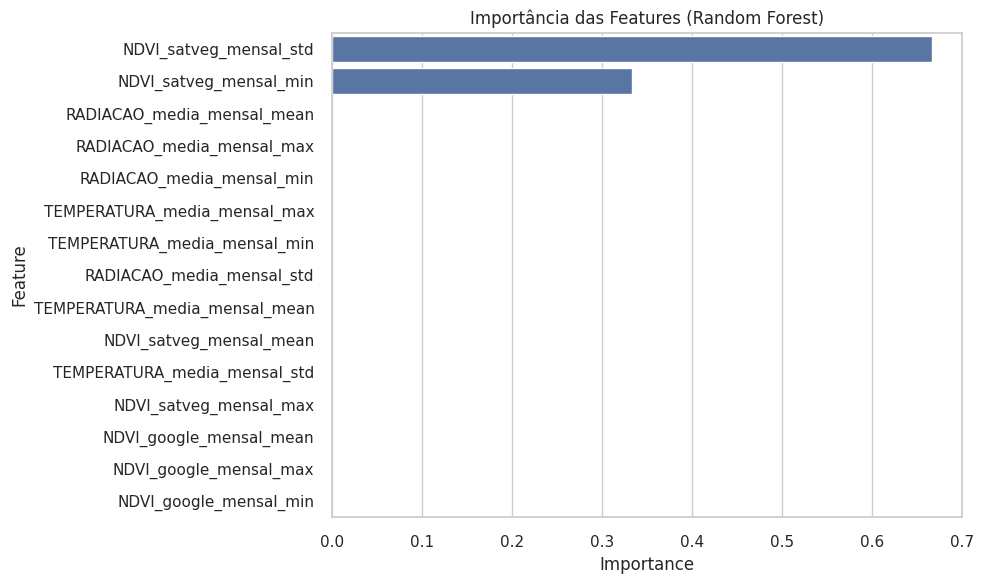

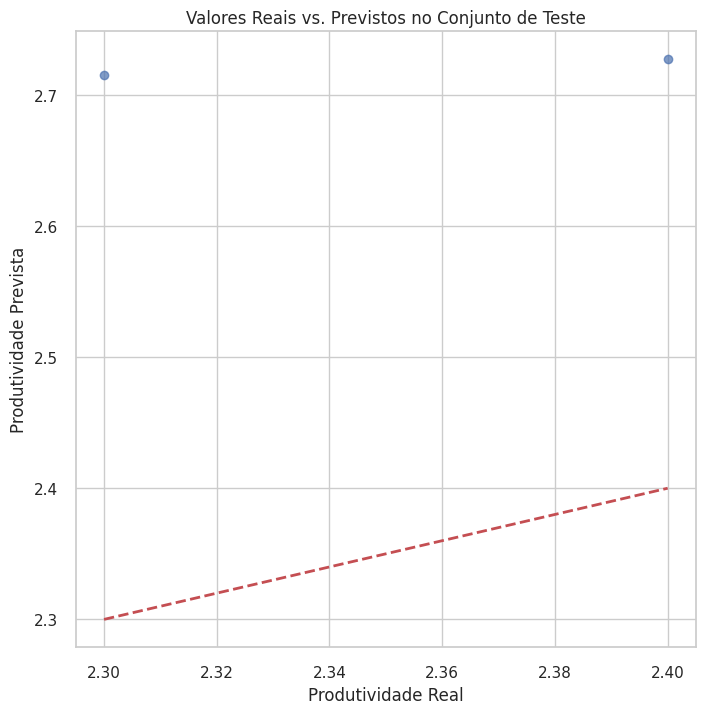


--- Salvando o Modelo Treinado ---
[OK] Melhor modelo RandomForest salvo em: resultados/modelos/modelo_produtividade_rf.joblib

--- Fim da Etapa 3 ---


In [156]:
# Etapa 3: Construção do Modelo de IA para Previsão de Produtividade

print(" Optamos pelo modelo Random Forest Regressor (Floresta Aleatória para Regressão.")
print(" - Administra bem a Não-Linearidade: Capaz de capturar relações complexas e não-lineares entre as variáveis (clima, NDVI, produtividade), que são comuns na agricultura.")
print(" - Robustez a Overfitting: Menos propenso a mascarar os dados de treino (overfitting) em comparação com uma única árvore de decisão, devido à combinação de múltiplas árvores.")
print(" - Análise de Importância: Fornece uma métrica (feature_importances_) que indica quais variáveis (temperatura, radiação, NDVI anual, etc.) tiveram maior influência na previsão da produtividade.")
print(" - Não Exige Escalonamento: Geralmente funciona bem mesmo que as variáveis de entrada (features) não estejam na mesma escala numérica, simplificando o pré-processamento.")

# Importar Bibliotecas
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys

print(" Iniciando Etapa 3: Construção do Modelo de IA")

# --- 1. Carregar Dados Consolidados ---
processed_folder = 'dados_processados'
consolidated_file_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv') # Usando a base mensal

try:
    df_mensal = pd.read_csv(consolidated_file_path)
    print(f"[OK] Base consolidada mensal carregada de: {consolidated_file_path}")
    print(f"     Dimensões: {df_mensal.shape}")

    if 'ANO' in df_mensal.columns:
         df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
         df_mensal.dropna(subset=['ANO'], inplace=True) # Remover linhas se ANO for inválido
    else:
         raise ValueError("Coluna 'ANO' não encontrada na base consolidada mensal.")

except FileNotFoundError:
    print(f"[Arquivo da base consolidada mensal não encontrado: {consolidated_file_path}")
    print("             Checar se a Etapa 2 foi executada e o arquivo salvo.")
    # sys.exit("Execução interrompida.") # Descomente para parar
except ValueError as ve:
     print(f"Problema ao processar coluna ANO: {ve}")
     # sys.exit("Execução interrompida.") # Descomente para parar
except Exception as e:
    print(f"Falha ao carregar ou processar a base consolidada mensal: {e}")
    # sys.exit("Execução interrompida.") # Descomente para parar

# --- 2. Engenharia de Atributos (Agregação Anual) ---
# Agrega os dados mensais por ano para criar features anuais.
print("\n--- Agregando Features Mensais Anualmente ---")

# Verifica se o DataFrame foi carregado
if 'df_mensal' in locals() and isinstance(df_mensal, pd.DataFrame):
    # Define as agregações desejadas para cada coluna numérica mensal
    # Ex: média anual, max anual, min anual, desvio padrão anual
    aggregations = {
        # Clima
        'RADIACAO_media_mensal': ['mean', 'max', 'min', 'std'],
        'TEMPERATURA_media_mensal': ['mean', 'max', 'min', 'std'],
        # NDVI SatVeg
        'NDVI_satveg_mensal': ['mean', 'max', 'min', 'std'],
        # NDVI Google
        'NDVI_google_mensal': ['mean', 'max', 'min', 'std'],
        'annual_mean_ndvi': ['first'], # Média anual já calculada, pega o primeiro valor do ano
        # Produtividade (Alvo) - Pega o primeiro valor (já deve ser único por ano)
        'Produtividade_Anual': ['first']
    }

    # Filtra o dicionário de agregações para incluir apenas colunas existentes no df_mensal
    agg_funcs_existentes = {}
    for col, funcs in aggregations.items():
        if col in df_mensal.columns:
            agg_funcs_existentes[col] = funcs
        else:
            print(f"  [AVISO] Coluna '{col}' não encontrada para agregação anual.")

    # Realiza a agregação anual
    if agg_funcs_existentes:
        df_anual = df_mensal.groupby('ANO').agg(agg_funcs_existentes)

        # Achata os nomes das colunas multi-nível (ex: ('RADIACAO_media_mensal', 'mean') -> 'RADIACAO_media_mensal_mean')
        df_anual.columns = ['_'.join(col).strip() for col in df_anual.columns.values]

        # Renomeia a coluna alvo para um nome mais simples
        target_col_agg = 'Produtividade_Anual_first'
        if target_col_agg in df_anual.columns:
            df_anual = df_anual.rename(columns={target_col_agg: 'Produtividade_Anual'})
        else:
            print(f"Coluna alvo '{target_col_agg}' não encontrada após agregação.")
            # Decide como proceder: parar ou continuar sem alvo?
            # sys.exit("Coluna alvo não encontrada.")

        # Remove linhas onde a produtividade anual é NaN
        if 'Produtividade_Anual' in df_anual.columns:
             linhas_antes = len(df_anual)
             df_anual.dropna(subset=['Produtividade_Anual'], inplace=True)
             removidos = linhas_antes - len(df_anual)
             if removidos > 0:
                  print(f"  {removidos} anos removidos por terem Produtividade_Anual ausente.")
        else:
             print("[ERRO] Coluna 'Produtividade_Anual' não presente no DataFrame anual.")
             # sys.exit()


        # Remove colunas que são totalmente NaN após agregação (se houver)
        df_anual.dropna(axis=1, how='all', inplace=True)

        # Resetar o índice para que 'ANO' volte a ser uma coluna (opcional, mas pode facilitar)
        # df_anual = df_anual.reset_index()

        print("[OK] Agregação anual concluída.")
        print(f"     Dimensões da base anual: {df_anual.shape}")
        print("     Primeiras linhas da base anual:")
        print(df_anual.head())
        print("\n     Colunas disponíveis na base anual:")
        print(df_anual.columns.tolist())

    else:
        print("Nenhuma coluna válida encontrada para realizar a agregação anual.")
        df_anual = None # Define como None se a agregação falhar
else:
    print("DataFrame mensal ('df_mensal') não está definido. Agregação anual não pode ser feita.")
    df_anual = None

# --- 3. Seleção de Atributos (Features) e Alvo (Target) ---
print("\n--- Selecionando Features e Target ---")

# Verifica se a base anual foi criada
if 'df_anual' in locals() and isinstance(df_anual, pd.DataFrame) and 'Produtividade_Anual' in df_anual.columns:
    # Define a variável alvo
    target = 'Produtividade_Anual'
    y = df_anual[target]

    # Definir as features (exceto o alvo)
    features_cols = [col for col in df_anual.columns if col != target]
    X = df_anual[features_cols]

    # Tratar NaNs restantes nas features
    if X.isnull().any().any():
         print("  [AVISO] Existem NaNs nas features. Preenchendo com a média da coluna...")
         X = X.fillna(X.mean()) # preencher NaNs com a média de cada coluna

    # Verificar se ainda aparece NaNs
    if X.isnull().any().any():
         print("  [ERRO] Ainda existem NaNs nas features após preenchimento. Verifique os dados.")


    print(f"[OK] Target definido: '{target}' ({len(y)} amostras)")
    print(f"[OK] Features definidas: {len(features_cols)} colunas ({X.shape[0]} amostras)")
    # print("     Nomes das Features:", features_cols) # Descomente para ver nomes

else:
    print("[ERRO] DataFrame anual ('df_anual') ou coluna 'Produtividade_Anual' não disponíveis.")
    # Define X e y como None para evitar erros posteriores
    X = None
    y = None
    # sys.exit() # Descomente para parar

# --- 4. Divisão Treino/Teste ---
print("\n--- Dividindo Dados em Treino e Teste ---")

# Verifica se X e y foram definidos corretamente
if X is not None and y is not None and not X.empty and not y.empty:
    try:
        # test_size=0.2 significa 20% para teste, 80% para treino
        # random_state=42 garante que a divisão seja a mesma sempre que rodar o código
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        print(f"[OK] Dados divididos:")
        print(f"     Treino: {X_train.shape[0]} amostras")
        print(f"     Teste:  {X_test.shape[0]} amostras")



    except Exception as e:
        print(f"[ERRO] Falha ao dividir os dados em treino/teste: {e}")
        X_train, X_test, y_train, y_test = None, None, None, None # Invalida em caso de erro
else:
    print("[ERRO] Features (X) ou Target (y) não estão prontos para divisão.")
    X_train, X_test, y_train, y_test = None, None, None, None

# --- 5. Seleção e Treinamento do Modelo (Random Forest) ---
print("\n--- Treinando Modelo RandomForestRegressor ---")

model = None # Inicializa modelo como None
if X_train is not None and y_train is not None:
    try:
        # Cria a instância do modelo
        # n_jobs=-1 usa todos os processadores disponíveis para acelerar
        model = RandomForestRegressor(random_state=42, n_jobs=-1)

        # Treina o modelo com os dados de treino
        model.fit(X_train, y_train) # Usar X_train_scaled se escalonou
        print("[OK] Modelo RandomForest treinado com sucesso (parâmetros padrão).")
    except Exception as e:
        print(f"[ERRO] Falha ao treinar o modelo RandomForest: {e}")
        model = None
else:
    print("[ERRO] Dados de treino (X_train, y_train) não disponíveis.")


# --- 6. Otimização (Ajuste de Hiperparâmetros com GridSearchCV) ---
print("\n--- Otimizando Hiperparâmetros com GridSearchCV ---")

best_model = None # Inicializa melhor modelo como None
if model is not None and X_train is not None and y_train is not None:
    try:
        # Define a grade de parâmetros a serem testados
        param_grid = {
            'n_estimators': [50, 100, 150],       # Número de árvores
            'max_depth': [None, 10, 20],         # Profundidade máxima das árvores (None = sem limite)
            'min_samples_split': [2, 5],         # Mínimo de amostras para dividir um nó
            'min_samples_leaf': [1, 3]           # Mínimo de amostras em um nó folha
            # 'max_features': ['auto', 'sqrt', 'log2'] # Número de features a considerar por split (removido 'auto' que é obsoleto)
        }

        # Configura o GridSearchCV
        # cv=5 significa validação cruzada com 5 folds
        # scoring='neg_mean_squared_error' -> GridSearchCV tenta maximizar, então usamos MSE negativo
        # n_jobs=-1 usa todos os processadores
        print("  Iniciando busca pelos melhores hiperparâmetros (pode levar alguns minutos)...")
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5,
                                   scoring='neg_mean_squared_error', n_jobs=-1, verbose=1) # verbose=1 mostra progresso

        # Executa a busca
        grid_search.fit(X_train, y_train) # Usar X_train_scaled se escalonou

        # Obtém o melhor modelo encontrado
        best_model = grid_search.best_estimator_
        print("\n[OK] Otimização concluída!")
        print(f"     Melhores Hiperparâmetros encontrados: {grid_search.best_params_}")
        print(f"     Melhor Score (neg_MSE) na validação cruzada: {grid_search.best_score_:.4f}")

    except Exception as e:
        print(f"[ERRO] Falha durante o GridSearchCV: {e}")
        print("       Usando o modelo treinado com parâmetros padrão (se disponível).")
        best_model = model # Usa o modelo não otimizado como fallback
else:
    print("[ERRO] Modelo ou dados de treino não disponíveis para otimização.")


# --- 7. Avaliação do Modelo no Conjunto de Teste ---
print("\n--- Avaliando o Melhor Modelo no Conjunto de Teste ---")

if best_model is not None and X_test is not None and y_test is not None:
    try:
        # Faz previsões no conjunto de teste
        y_pred = best_model.predict(X_test) # Usar X_test_scaled se escalonou

        # Calcula as métricas de avaliação
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)

        print("[OK] Métricas de Avaliação no Conjunto de Teste:")
        print(f"     R-quadrado (R²): {r2:.4f}")
        print(f"     Erro Quadrático Médio (MSE): {mse:.4f}")
        print(f"     Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")
        print(f"     Erro Absoluto Médio (MAE): {mae:.4f}")

        # Análise de Importância das Features
        if hasattr(best_model, 'feature_importances_'):
            print("\n     Importância das Features:")
            importances = best_model.feature_importances_
            feature_names = X_train.columns # Assume que X_train tem nomes de colunas
            feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
            print(feature_importance_df)

            # Plotar importância das features
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15)) # Top 15 features
            plt.title('Importância das Features (Random Forest)')
            plt.tight_layout()
            plt.show()

        # Gráfico de Dispersão: Real vs Previsto
        plt.figure(figsize=(8, 8))
        plt.scatter(y_test, y_pred, alpha=0.7)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Linha ideal (y=x)
        plt.xlabel('Produtividade Real')
        plt.ylabel('Produtividade Prevista')
        plt.title('Valores Reais vs. Previstos no Conjunto de Teste')
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"[ERRO] Falha ao avaliar o modelo no conjunto de teste: {e}")
else:
    print("[ERRO] Melhor modelo ou dados de teste não disponíveis para avaliação.")


# --- 8. Salvar o Modelo Treinado ---
print("\n--- Salvando o Modelo Treinado ---")
model_folder = os.path.join('resultados', 'modelos')
os.makedirs(model_folder, exist_ok=True) # Cria a pasta de modelos se não existir
model_path = os.path.join(model_folder, 'modelo_produtividade_rf.joblib')

if best_model is not None:
    try:
        joblib.dump(best_model, model_path)
        print(f"[OK] Melhor modelo RandomForest salvo em: {model_path}")
    except Exception as e:
        print(f"[ERRO] Falha ao salvar o modelo: {e}")
else:
    print("[AVISO] Nenhum modelo treinado disponível para salvar.")


print("\n--- Fim da Etapa 3 ---")


# Etapa 4



*   Testar o modelo com diferentes períodos de dados, avaliando sua precisão e confiabilidade.
*   Ajustar a estratégia de modelagem com base nos resultados obtidos.
*   Gerar visualizações e métricas de desempenho para demonstrar os insights obtidos.





--- Iniciando Etapa 4: Teste com Validação Cruzada Temporal ---
[OK] Modelo treinado carregado de: resultados/modelos/modelo_produtividade_rf.joblib
  Parâmetros do modelo carregado (exemplo): n_estimators=150

[INFO] Recriando base anual (X, y) a partir da base mensal consolidada...
[OK] Base anual (X, y) recriada e ordenada por ano.
     Número de anos disponíveis para modelagem: 7

--- Implementando Validação Cruzada Temporal ---
  Configurando TimeSeriesSplit com 4 divisões.
  -> Em cada divisão, o modelo será treinado com dados passados e testado em dados futuros.

  --- Fold 1/4 ---
    Anos de Treino: [2015, 2016, 2018]
    Anos de Teste : [2019]
    Modelo treinado para o Fold 1.
    Previsões realizadas para o(s) ano(s) [2019].
    Métricas do Fold 1: R²=nan, RMSE=0.1316, MAE=0.1316


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


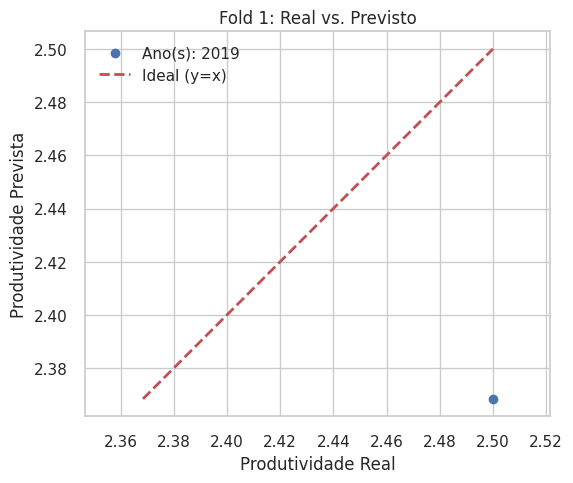


  --- Fold 2/4 ---
    Anos de Treino: [2015, 2016, 2018, 2019]
    Anos de Teste : [2020]
    Modelo treinado para o Fold 2.
    Previsões realizadas para o(s) ano(s) [2020].
    Métricas do Fold 2: R²=nan, RMSE=0.4008, MAE=0.4008


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


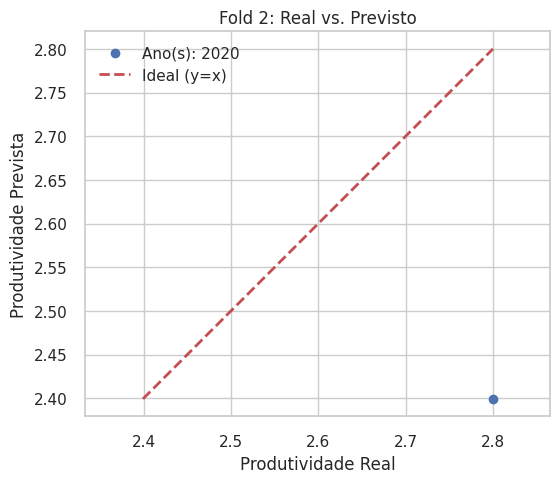


  --- Fold 3/4 ---
    Anos de Treino: [2015, 2016, 2018, 2019, 2020]
    Anos de Teste : [2023]
    Modelo treinado para o Fold 3.
    Previsões realizadas para o(s) ano(s) [2023].
    Métricas do Fold 3: R²=nan, RMSE=0.4107, MAE=0.4107


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


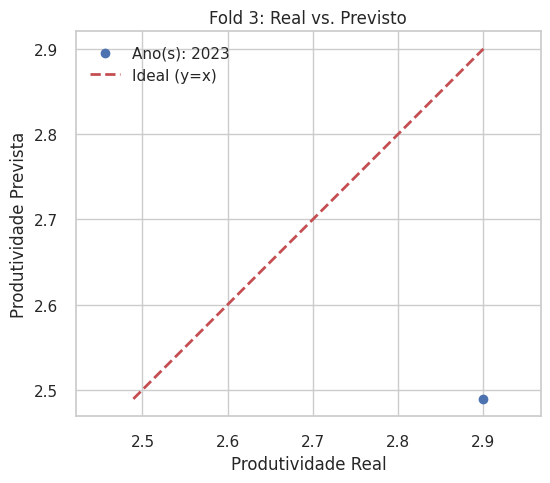


  --- Fold 4/4 ---
    Anos de Treino: [2015, 2016, 2018, 2019, 2020, 2023]
    Anos de Teste : [2024]
    Modelo treinado para o Fold 4.
    Previsões realizadas para o(s) ano(s) [2024].
    Métricas do Fold 4: R²=nan, RMSE=0.4016, MAE=0.4016


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


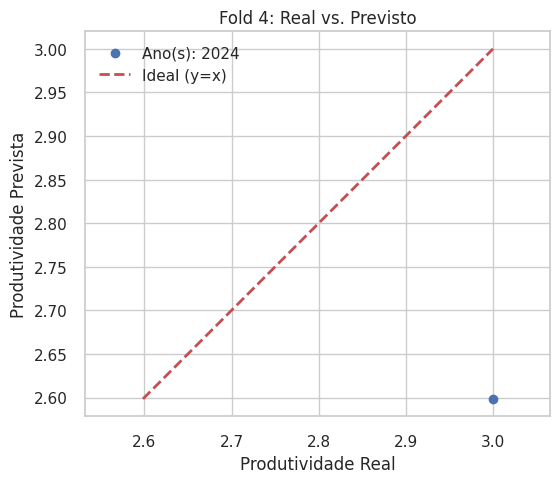


  --- Resultados Consolidados da Validação Cruzada Temporal ---
    Nenhuma métrica válida foi calculada durante a validação cruzada.

--- Fim da Validação Cruzada Temporal ---


In [160]:
# Etapa 4 - Teste com Validação Cruzada Temporal

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
import joblib # Para carregar o modelo salvo
from sklearn.model_selection import TimeSeriesSplit # Para validação cruzada temporal
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Etapa 4: Teste com Validação Cruzada Temporal ---")

# --- 1. Carregar Artefatos Necessários ---
processed_folder = 'dados_processados'
results_folder = 'resultados'
model_folder = os.path.join(results_folder, 'modelos')
model_path = os.path.join(model_folder, 'modelo_produtividade_rf.joblib')
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')

model_params = None
df_anual = None
X = None
y = None

# Carregar os parâmetros do modelo (ou usar padrão)
try:
    best_model_loaded = joblib.load(model_path)
    print(f"[OK] Modelo treinado carregado de: {model_path}")
    model_params = best_model_loaded.get_params()
    print(f"  Parâmetros do modelo carregado (exemplo): n_estimators={model_params.get('n_estimators', 'N/A')}")
except FileNotFoundError:
    print(f"[AVISO] Arquivo do modelo não encontrado: {model_path}. Usando RandomForest com params padrão.")
    model_params = {'random_state': 42, 'n_jobs': -1} # Parâmetros padrão
except Exception as e:
    print(f"[ERRO] Falha ao carregar o modelo: {e}. Usando RandomForest com params padrão.")
    model_params = {'random_state': 42, 'n_jobs': -1}

# Recriar Dados Anuais (X e y) a partir da base mensal
print("\n[INFO] Recriando base anual (X, y) a partir da base mensal consolidada...")
try:
    # 1. Recarregar base mensal
    df_mensal = pd.read_csv(consolidated_monthly_path)
    if 'ANO' in df_mensal.columns:
        df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
        df_mensal.dropna(subset=['ANO'], inplace=True)
    else:
        raise ValueError("Coluna 'ANO' não encontrada na base mensal.")

    # 2. Re-executar a agregação anual
    aggregations = {
        'RADIACAO_media_mensal': ['mean', 'max', 'min', 'std'],
        'TEMPERATURA_media_mensal': ['mean', 'max', 'min', 'std'],
        'NDVI_satveg_mensal': ['mean', 'max', 'min', 'std'],
        'NDVI_google_mensal': ['mean', 'max', 'min', 'std'],
        'annual_mean_ndvi': ['first'],
        'Produtividade_Anual': ['first']
    }
    agg_funcs_existentes = {col: funcs for col, funcs in aggregations.items() if col in df_mensal.columns}
    if not agg_funcs_existentes:
        raise ValueError("Nenhuma coluna válida para agregação anual encontrada.")

    df_anual = df_mensal.groupby('ANO').agg(agg_funcs_existentes)
    df_anual.columns = ['_'.join(col).strip() for col in df_anual.columns.values]
    target_col_agg = 'Produtividade_Anual_first'
    if target_col_agg in df_anual.columns:
        df_anual = df_anual.rename(columns={target_col_agg: 'Produtividade_Anual'})
    else:
        raise ValueError("Coluna alvo não encontrada após agregação.")
    df_anual.dropna(subset=['Produtividade_Anual'], inplace=True) # Remove anos sem produtividade
    df_anual.dropna(axis=1, how='all', inplace=True) # Remove colunas totalmente NaN

    # *** GARANTIR ORDENAÇÃO POR ANO (CRUCIAL PARA TimeSeriesSplit) ***
    df_anual = df_anual.sort_index() # Ordena pelo índice (ANO)

    if df_anual.empty:
        raise ValueError("DataFrame anual ficou vazio após agregação/limpeza.")

    # 3. Refazer a seleção de Features/Target e preenchimento de NaNs
    target = 'Produtividade_Anual'
    y = df_anual[target]
    features_cols = [col for col in df_anual.columns if col != target]
    X = df_anual[features_cols]
    if X.isnull().any().any():
        print("  [AVISO] Preenchendo NaNs nas features com a média da coluna...")
        numeric_cols = X.select_dtypes(include=np.number).columns
        means = X[numeric_cols].mean()
        X.fillna(means, inplace=True) # Preenche com a média
        if X.isnull().any().any():
             cols_com_nan_final = X.columns[X.isnull().any()].tolist()
             print(f"  [ERRO] NaNs persistentes nas features após preenchimento: {cols_com_nan_final}. Removendo colunas...")
             X = X.dropna(axis=1, how='any')
             features_cols = X.columns.tolist()

    print("[OK] Base anual (X, y) recriada e ordenada por ano.")
    print(f"     Número de anos disponíveis para modelagem: {len(df_anual)}")
    # print(f"     Features consideradas: {features_cols}") # Descomente para ver as features

except FileNotFoundError:
    print(f"[ERRO CRÍTICO] Arquivo base mensal '{consolidated_monthly_path}' não encontrado.")
    X, y = None, None
except ValueError as ve:
    print(f"[ERRO CRÍTICO] Problema ao recriar dados anuais: {ve}")
    X, y = None, None
except Exception as e:
    print(f"[ERRO CRÍTICO] Falha inesperada ao recriar dados anuais: {e}")
    X, y = None, None


# --- 2. Validação Cruzada Temporal (Time Series Cross-Validation) ---
print("\n--- Implementando Validação Cruzada Temporal ---")

# Verifica se X e y estão prontos
if X is not None and y is not None and not X.empty and not y.empty:
    n_anos = len(X)
    # Define o número de splits (divisões). Ex: 4 splits testam os últimos 4 anos.
    # O número máximo de splits é n_anos - 1. Usamos min(4, n_anos - 1) como padrão.
    n_splits_ts = min(4, n_anos - 1) if n_anos > 1 else 0

    # Verifica se é possível fazer a validação cruzada (precisa de pelo menos 2 splits)
    if n_splits_ts >= 2:
        tscv = TimeSeriesSplit(n_splits=n_splits_ts)
        print(f"  Configurando TimeSeriesSplit com {n_splits_ts} divisões.")
        print("  -> Em cada divisão, o modelo será treinado com dados passados e testado em dados futuros.")

        # Listas para armazenar as métricas de cada fold (divisão)
        fold_metrics = {'r2': [], 'rmse': [], 'mae': []}
        fold_counter = 0

        # Itera sobre as divisões treino/teste geradas pelo TimeSeriesSplit
        # Os dados já estão ordenados por ano (índice)
        for train_index, test_index in tscv.split(X):
            fold_counter += 1
            print(f"\n  --- Fold {fold_counter}/{n_splits_ts} ---")

            # Seleciona os dados de treino e teste para esta divisão usando os índices
            X_train_ts, X_test_ts = X.iloc[train_index], X.iloc[test_index]
            y_train_ts, y_test_ts = y.iloc[train_index], y.iloc[test_index]

            # Mostra os anos usados em cada conjunto
            anos_treino = X_train_ts.index.tolist()
            anos_teste = X_test_ts.index.tolist()
            print(f"    Anos de Treino: {anos_treino}")
            print(f"    Anos de Teste : {anos_teste}")

            try:
                # Cria uma NOVA instância do modelo RandomForest para treinar neste fold
                # Usa os parâmetros carregados do modelo salvo ou os parâmetros padrão
                fold_model = RandomForestRegressor(**model_params)

                # Treina o modelo no conjunto de treino específico deste fold
                fold_model.fit(X_train_ts, y_train_ts)
                print(f"    Modelo treinado para o Fold {fold_counter}.")

                # Faz previsões no conjunto de teste específico deste fold
                y_pred_ts = fold_model.predict(X_test_ts)
                print(f"    Previsões realizadas para o(s) ano(s) {anos_teste}.")

                # Calcula e armazena as métricas de desempenho para este fold
                r2_fold = r2_score(y_test_ts, y_pred_ts)
                rmse_fold = np.sqrt(mean_squared_error(y_test_ts, y_pred_ts))
                mae_fold = mean_absolute_error(y_test_ts, y_pred_ts)

                fold_metrics['r2'].append(r2_fold)
                fold_metrics['rmse'].append(rmse_fold)
                fold_metrics['mae'].append(mae_fold)

                print(f"    Métricas do Fold {fold_counter}: R²={r2_fold:.4f}, RMSE={rmse_fold:.4f}, MAE={mae_fold:.4f}")

                # Opcional: Plotar Real vs Previsto para este fold específico
                plt.figure(figsize=(6, 5))
                plt.scatter(y_test_ts, y_pred_ts, label=f'Ano(s): {",".join(map(str, anos_teste))}')
                # Linha ideal y=x
                min_val_ts = min(y_test_ts.min(), y_pred_ts.min())
                max_val_ts = max(y_test_ts.max(), y_pred_ts.max())
                plt.plot([min_val_ts, max_val_ts], [min_val_ts, max_val_ts], '--r', linewidth=2, label='Ideal (y=x)')
                plt.xlabel('Produtividade Real')
                plt.ylabel('Produtividade Prevista')
                plt.title(f'Fold {fold_counter}: Real vs. Previsto')
                plt.legend()
                plt.grid(True)
                plt.axis('equal') # Garante escalas iguais nos eixos
                plt.show()

            except Exception as e_fold:
                print(f"    [ERRO] Falha ao treinar/avaliar o Fold {fold_counter}: {e_fold}")
                # Adiciona NaN às métricas se o fold falhar para manter o tamanho das listas
                fold_metrics['r2'].append(np.nan)
                fold_metrics['rmse'].append(np.nan)
                fold_metrics['mae'].append(np.nan)

        # --- 3. Calcular e Exibir Métricas Médias da Validação Cruzada Temporal ---
        print("\n  --- Resultados Consolidados da Validação Cruzada Temporal ---")
        # Verifica se há métricas válidas para calcular a média
        if fold_metrics['r2'] and not all(np.isnan(m) for m in fold_metrics['r2']):
             print("    Métricas (Média ± Desvio Padrão dos Folds):")
             print(f"      R² Médio    : {np.nanmean(fold_metrics['r2']):.4f} ± {np.nanstd(fold_metrics['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics['rmse']):.4f} ± {np.nanstd(fold_metrics['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics['mae']):.4f} ± {np.nanstd(fold_metrics['mae']):.4f}")
             print("\n    -> Estas métricas médias dão uma estimativa mais robusta do desempenho esperado")
             print("       do modelo em dados futuros (não vistos durante o treino de cada fold).")
             print("    -> Compare com as métricas da divisão simples (80/20) para ver a consistência.")
        else:
             print("    Nenhuma métrica válida foi calculada durante a validação cruzada.")

    # Mensagens caso não seja possível executar a validação cruzada
    elif n_anos <= 1:
         print(f"[AVISO] Número de anos ({n_anos}) insuficiente para TimeSeriesSplit (requer >= 2).")
    else:
         print(f"[AVISO] Número de splits ({n_splits_ts}) inválido ou insuficiente (requer >= 2). Validação Cruzada Temporal não executada.")
else:
    print("[ERRO] Dados anuais (X, y) não disponíveis para Validação Cruzada Temporal.")

print("\n--- Fim da Validação Cruzada Temporal ---")


In [162]:
# Ajustar a estratégia de modelagem com base nos resultados obtidos

print ("A principal limitação é a quantidade de dados (anos).")
print ("Com apenas 7 pontos de dados anuais, qualquer modelo treinado terá alta incerteza e a validação será pouco confiável.")
print ("Escolhemos um periodo reduzido, pois como tinha que incluir as imagens (pesadas nas analises, estava demorando muito pra rodar")


A principal limitação é a quantidade de dados (anos).
Com apenas 7 pontos de dados anuais, qualquer modelo treinado terá alta incerteza e a validação será pouco confiável.
Escolhemos um periodo reduzido, pois como tinha que incluir as imagens (pesadas nas analises, estava demorando muito pra rodar
